# ST422 Brief 8 — Road Safety Analysis
## Combined Analysis Notebook

**Purpose:** Loads STATS19 data, cleans and merges, performs EDA, trend analysis,
hotspot identification, contributory factor analysis, robustness checks,
uncertainty quantification, and OLS diagnostics.

**Inputs:**
- `Data/` — raw DfT STATS19 CSVs (see README.md for filenames)
- `Cleaned/cas_full.csv` — produced by ST422_DataPrep.ipynb

**Outputs:**
- `outputs/fig_*.png` — all figures saved for traceability
- `outputs/tab_*.csv` — all key tables saved for traceability

**Run order:** Run ST422_DataPrep.ipynb first, then this notebook top to bottom.
Restart kernel before a full re-run to guarantee a clean state.


## 0. Config and Setup

In [4]:
# ── USER CONFIG ───────────────────────────────────────────────────────────────
# No path editing required — all paths are relative to project root.
import os

NOTEBOOK_DIR = os.getcwd()
DATA_DIR     = os.path.join(NOTEBOOK_DIR, 'Data')
CLEANED_DIR  = os.path.join(NOTEBOOK_DIR, 'Cleaned')
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Year windows
YEAR_START       = 2014
YEAR_END         = 2024
COVID_YEARS      = [2020, 2021]
BASE_YEARS       = [2015, 2016, 2017]
RECENT_YEARS     = [2022, 2023, 2024]

# OLS thresholds (Week 10)
MIN_KSI_BASE = 30
MIN_YEARS    = 6
LOW_R2       = 0.5
TOP_N        = 5
TOP_N_LINES  = 3

# File paths
COLLISION_HIST = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-collision-1979-latest-published-year.csv')
CASUALTY_HIST  = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-casualty-1979-latest-published-year.csv')
VEHICLE_HIST   = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-vehicle-1979-latest-published-year.csv')
COLLISION_PROV = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-collision-provisional-2025.csv')
CASUALTY_PROV  = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-casualty-provisional-2025.csv')
VEHICLE_PROV   = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-vehicle-provisional-2025.csv')
LA_LOOKUP      = os.path.join(DATA_DIR, 'local-authority-ons-district-names.csv')
CAS_FULL       = os.path.join(CLEANED_DIR, 'cas_full.csv')

print('DATA_DIR   :', DATA_DIR,    '| exists:', os.path.exists(DATA_DIR))
print('CLEANED_DIR:', CLEANED_DIR, '| exists:', os.path.exists(CLEANED_DIR))
print('OUTPUT_DIR :', OUTPUT_DIR,  '| exists:', os.path.exists(OUTPUT_DIR))


DATA_DIR   : C:\Users\u2211111\Data | exists: True
CLEANED_DIR: C:\Users\u2211111\Cleaned | exists: True
OUTPUT_DIR : C:\Users\u2211111\outputs | exists: True


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'figure.dpi': 120
})

DTYPE = {'collision_index': str, 'collision_ref_no': str}

def savefig(name):
    """Save current figure to outputs/ folder."""
    path = os.path.join(OUTPUT_DIR, f'{name}.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    print(f'Saved: {path}')


---
## 1. Data Load and Preparation

Loads the full STATS19 historical files (2014–2024) and provisional 2025 data.
Invalid codes (-1) replaced with NaN. Derived columns and label maps applied.


In [6]:
# Load historical files
col_hist = pd.read_csv(COLLISION_HIST, dtype=DTYPE, low_memory=False)
cas_hist = pd.read_csv(CASUALTY_HIST,  dtype=DTYPE, low_memory=False)
veh_hist = pd.read_csv(VEHICLE_HIST,   dtype=DTYPE, low_memory=False)
for df in [col_hist, cas_hist, veh_hist]:
    df.columns = df.columns.str.lower()
col_hist = col_hist[col_hist['collision_year'].between(YEAR_START, YEAR_END)].copy()
cas_hist = cas_hist[cas_hist['collision_year'].between(YEAR_START, YEAR_END)].copy()
veh_hist = veh_hist[veh_hist['collision_year'].between(YEAR_START, YEAR_END)].copy()

# Load and append provisional 2025
col_prov = pd.read_csv(COLLISION_PROV, dtype=DTYPE, low_memory=False)
cas_prov = pd.read_csv(CASUALTY_PROV,  dtype=DTYPE, low_memory=False)
veh_prov = pd.read_csv(VEHICLE_PROV,   dtype=DTYPE, low_memory=False)
for df in [col_prov, cas_prov, veh_prov]:
    df.columns = df.columns.str.lower()
    df['provisional'] = True

col = pd.concat([col_hist, col_prov], ignore_index=True)
cas = pd.concat([cas_hist, cas_prov], ignore_index=True)
veh = pd.concat([veh_hist, veh_prov], ignore_index=True)
for df in [col, cas, veh]:
    df['provisional'] = df.get('provisional', False).fillna(False)

YEARS = sorted(col['collision_year'].dropna().unique().astype(int).tolist())
print(f'col: {len(col):,}  cas: {len(cas):,}  veh: {len(veh):,}')
print(f'Years: {YEARS}')


col: 1,345,099  cas: 1,748,311  veh: 2,469,085
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [7]:
# Clean coded fields — replace -1 with NaN
CODED_COL = ['collision_severity','enhanced_severity_collision','speed_limit','road_type',
             'junction_detail','junction_control','light_conditions','urban_or_rural_area',
             'police_force','collision_injury_based','day_of_week','weather_conditions','road_surface_conditions']
CODED_CAS = ['casualty_severity','enhanced_casualty_severity','casualty_type','casualty_class',
             'age_of_casualty','age_band_of_casualty','sex_of_casualty','casualty_imd_decile','casualty_injury_based']
CODED_VEH = ['vehicle_type','sex_of_driver','age_of_driver','age_band_of_driver',
             'journey_purpose_of_driver','driver_imd_decile','propulsion_code']

for fields, df in [(CODED_COL, col), (CODED_CAS, cas), (CODED_VEH, veh)]:
    for f in fields:
        if f in df.columns:
            df[f] = pd.to_numeric(df[f], errors='coerce')
            df.loc[df[f] < 0, f] = np.nan

# Derived columns
col['date']  = pd.to_datetime(col['date'], dayfirst=True, errors='coerce')
col['month'] = col['date'].dt.month
col['ksi']   = col['collision_severity'].isin([1, 2])
col['fatal'] = col['collision_severity'] == 1

# Label maps
GROUPED_MAP  = {1:'Pedestrian',2:'Cyclist',3:'Motorcycle rider',4:'Motorcycle rider',
                5:'Motorcycle rider',23:'Motorcycle rider',97:'Motorcycle rider',
                8:'Taxi/PHV occupant',9:'Car occupant',10:'Minibus/bus occupant',
                11:'Minibus/bus occupant',19:'Van occupant',20:'HGV occupant',21:'HGV occupant',
                16:'Other',17:'Other',18:'Other',22:'Other',90:'Other',98:'Unknown',99:'Unknown'}
URBAN_MAP    = {1:'Urban',2:'Rural',3:'Unallocated'}
ROAD_MAP     = {1:'Roundabout',2:'One way street',3:'Dual carriageway',
                6:'Single carriageway',7:'Slip road',9:'Unknown',12:'One way/Slip road'}
JUNCTION_MAP = {0:'Not at junction',13:'T or Y junction',16:'Crossroads',
                17:'More than 4 arms',18:'Private drive or entrance',19:'Other junction',99:'Unknown'}
DAY_MAP      = {1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri',7:'Sat'}
FORCE_MAP    = {1:'Metropolitan Police',3:'Cumbria',4:'Lancashire',5:'Merseyside',
                6:'Greater Manchester',7:'Cheshire',10:'Humberside',11:'West Yorkshire',
                12:'South Yorkshire',13:'West Midlands',14:'East Midlands',16:'Staffordshire',
                17:'West Mercia',20:'Thames Valley',21:'Hampshire',22:'South East',
                23:'Essex',24:'Norfolk',25:'Suffolk',26:'Bedfordshire',27:'Hertfordshire',
                30:'Cambridgeshire',31:'Northamptonshire',32:'Leicestershire',33:'Warwickshire',
                34:'Avon and Somerset',35:'Gloucestershire',36:'Wiltshire',37:'Dorset',
                38:'Devon and Cornwall',39:'Sussex',40:'Kent',41:'Surrey',42:'Northumbria',
                43:'Durham',44:'North Yorkshire',45:'Dyfed-Powys',46:'Gwent',47:'South Wales',
                48:'North Wales',50:'Lincolnshire',52:'Cleveland',53:'City of London',
                54:'Nottinghamshire',55:'Derbyshire',99:'Unknown/Other'}

cas['road_user']       = cas['casualty_type'].map(GROUPED_MAP).fillna('Unknown')
col['ur_label']        = col['urban_or_rural_area'].map(URBAN_MAP)
col['road_type_label'] = col['road_type'].map(ROAD_MAP)
col['junction_label']  = col['junction_detail'].map(JUNCTION_MAP)
col['day_label']       = col['day_of_week'].map(DAY_MAP)
col['force_name']      = col['police_force'].map(FORCE_MAP).fillna('Unknown')

la_lookup = pd.read_csv(LA_LOOKUP)[['code','la_name']].rename(columns={'code':'local_authority_ons_district'})
col = col.merge(la_lookup, on='local_authority_ons_district', how='left')
print('Cleaning and label maps complete.')
print(f'col: {col.shape}  cas: {cas.shape}  veh: {veh.shape}')


Cleaning and label maps complete.
col: (1347870, 54)  cas: (1748311, 25)  veh: (2469085, 33)


---
## 2. Exploratory Analysis and Descriptive Checks

**EDA objectives:** Before any modelling, we check (1) data completeness and
missingness patterns, (2) IBRS adoption — the most important data quality issue
for this analysis, (3) geographic and temporal coverage gaps, (4) coordinate
quality for hotspot mapping, and (5) distributional checks on the primary outcome.
These checks inform which fields can be used reliably and which require caveating.


In [8]:
# 2.1 Missingness summary
NON_NEGATIVE_CHECK = CODED_COL + CODED_CAS + CODED_VEH

def missingness(df, fields):
    rows = []
    for f in fields:
        if f not in df.columns:
            rows.append({'Field': f, 'Missing (n)': '-', 'Missing (%)': '-'})
            continue
        if f in NON_NEGATIVE_CHECK:
            null_mask = df[f].isna() | (pd.to_numeric(df[f], errors='coerce') < 0)
        else:
            null_mask = df[f].isna()
        n   = null_mask.sum()
        pct = n / len(df) * 100
        flag = '  *** HIGH ***' if pct > 5 else ''
        rows.append({'Field': f, 'Missing (n)': f'{n:,}', 'Missing (%)': f'{pct:.1f}%{flag}'})
    return pd.DataFrame(rows)

key_col = ['collision_severity','enhanced_severity_collision','date','latitude','longitude',
           'speed_limit','road_type','junction_detail','light_conditions','urban_or_rural_area',
           'collision_injury_based','collision_adjusted_severity_serious']
print('=== Collision table missingness ===')
display(missingness(col, key_col))


=== Collision table missingness ===


,Field,Missing (n),Missing (%)
0,collision_severity,0,0.0%
1,enhanced_severity_collision,"859,238",63.7% *** HIGH ***
2,date,0,0.0%
3,latitude,203,0.0%
4,longitude,203,0.0%
5,speed_limit,317,0.0%
6,road_type,1,0.0%
7,junction_detail,"23,095",1.7%
8,light_conditions,341,0.0%
9,urban_or_rural_area,9,0.0%


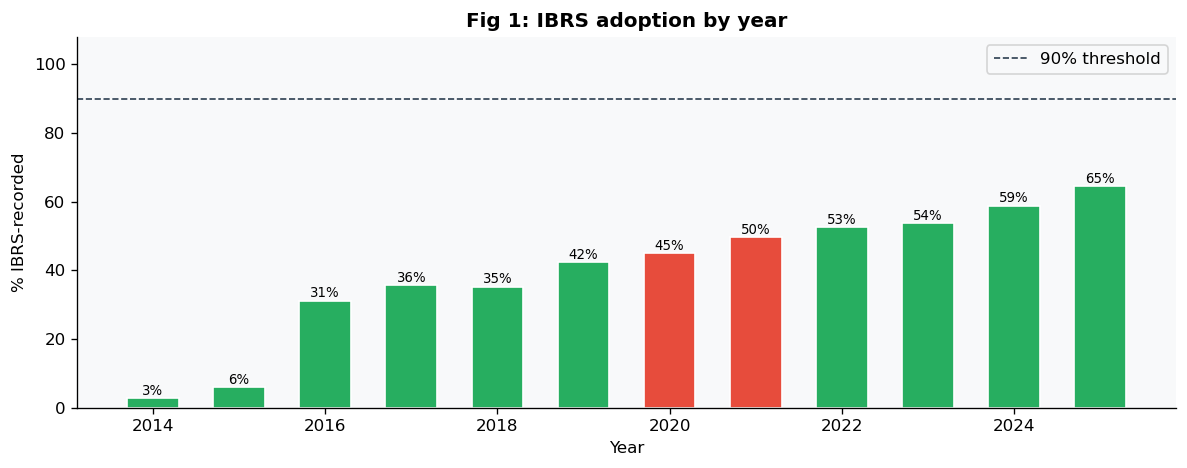

Saved: C:\Users\u2211111\outputs\fig_01_ibrs_adoption.png
 year  ibrs_pct
 2014       2.7
 2015       5.9
 2016      31.2
 2017      35.6
 2018      35.2
 2019      42.3
 2020      45.0
 2021      49.7
 2022      52.6
 2023      53.8
 2024      58.8
 2025      64.6


<Figure size 768x576 with 0 Axes>

In [9]:
# 2.2 IBRS adoption by year
ibrs = (col.groupby('collision_year')['collision_injury_based']
        .apply(lambda x: (x==1).sum()/len(x)*100).reset_index())
ibrs.columns = ['year','ibrs_pct']
ibrs['ibrs_pct'] = ibrs['ibrs_pct'].round(1)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if y in COVID_YEARS else '#27ae60' for y in ibrs['year']]
bars = ax.bar(ibrs['year'], ibrs['ibrs_pct'], color=colors, width=0.6, edgecolor='white')
ax.axhline(90, color='#2c3e50', linestyle='--', linewidth=1, label='90% threshold')
for bar, val in zip(bars, ibrs['ibrs_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.0f}%', ha='center', fontsize=8)
ax.set_ylim(0, 108)
ax.set_xlabel('Year'); ax.set_ylabel('% IBRS-recorded')
ax.set_title('Fig 1: IBRS adoption by year', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show(); savefig('fig_01_ibrs_adoption')
print(ibrs.to_string(index=False))


In [10]:
# 2.3 Severity distribution by year — distributional check
sev = col.groupby(['collision_year','collision_severity']).size().unstack(fill_value=0)
sev = sev.rename(columns={1:'Fatal',2:'Serious',3:'Slight'})
sev['KSI']   = sev['Fatal'] + sev['Serious']
sev['Total'] = sev[['Fatal','Serious','Slight']].sum(axis=1)
sev['Serious/Slight'] = (sev['Serious']/sev['Slight']).round(3)
sev['KSI%'] = (sev['KSI']/sev['Total']*100).round(1)
print('Severity breakdown by year:')
display(sev[['Fatal','Serious','Slight','KSI','Serious/Slight','KSI%']])
sev[['Fatal','Serious','Slight','KSI','Serious/Slight','KSI%']].to_csv(
    os.path.join(OUTPUT_DIR,'tab_severity_by_year.csv'))
print('Note: rising Serious/Slight ratio reflects IBRS adoption, not necessarily genuine change.')


Severity breakdown by year:


collision_severity,Fatal,Serious,Slight,KSI,Serious/Slight,KSI%
collision_year,,,,,,
2014,1662,20697,124311,22359,0.166,15.2
2015,1617,20023,118760,21640,0.169,15.4
2016,1697,21525,113767,23222,0.189,17.0
2017,1678,22412,106205,24090,0.211,18.5
2018,1672,23048,98184,24720,0.235,20.1
2019,1659,23042,93117,24701,0.247,21.0
2020,1391,18390,71525,19781,0.257,21.7
2021,1475,21324,78435,22799,0.272,22.5
2022,1603,23392,81184,24995,0.288,23.5


Note: rising Serious/Slight ratio reflects IBRS adoption, not necessarily genuine change.


In [11]:
# 2.4 Geographic and temporal coverage
force_yr = col.groupby(['collision_year','police_force']).size().unstack(fill_value=0)
forces_per_year = (force_yr > 0).sum(axis=1)
print('Forces reporting per year:')
print(forces_per_year.to_string())

valid = col['latitude'].notna() & col['longitude'].notna() & (col['latitude'] != 0)
in_gb = valid & col['latitude'].between(49.5,61.0) & col['longitude'].between(-8.0,2.0)
print(f'\nValid coordinates : {valid.sum():,}  ({valid.sum()/len(col)*100:.1f}%)')
print(f'Within GB bounds  : {in_gb.sum():,}  ({in_gb.sum()/len(col)*100:.1f}%)')


Forces reporting per year:
collision_year
2014    51
2015    51
2016    51
2017    51
2018    51
2019    51
2020    44
2021    44
2022    44
2023    44
2024    44
2025    44

Valid coordinates : 1,347,667  (100.0%)
Within GB bounds  : 1,347,667  (100.0%)


---
## 3. KSI Trends (2014–2024)

Long-term trend analysis using the full 11-year window. Key question: is the
apparent rise in raw KSI since 2016 a genuine deterioration or a recording
artefact from IBRS adoption? Fatal collisions are used as a benchmark since
fatality recording is unaffected by the IBRS transition.


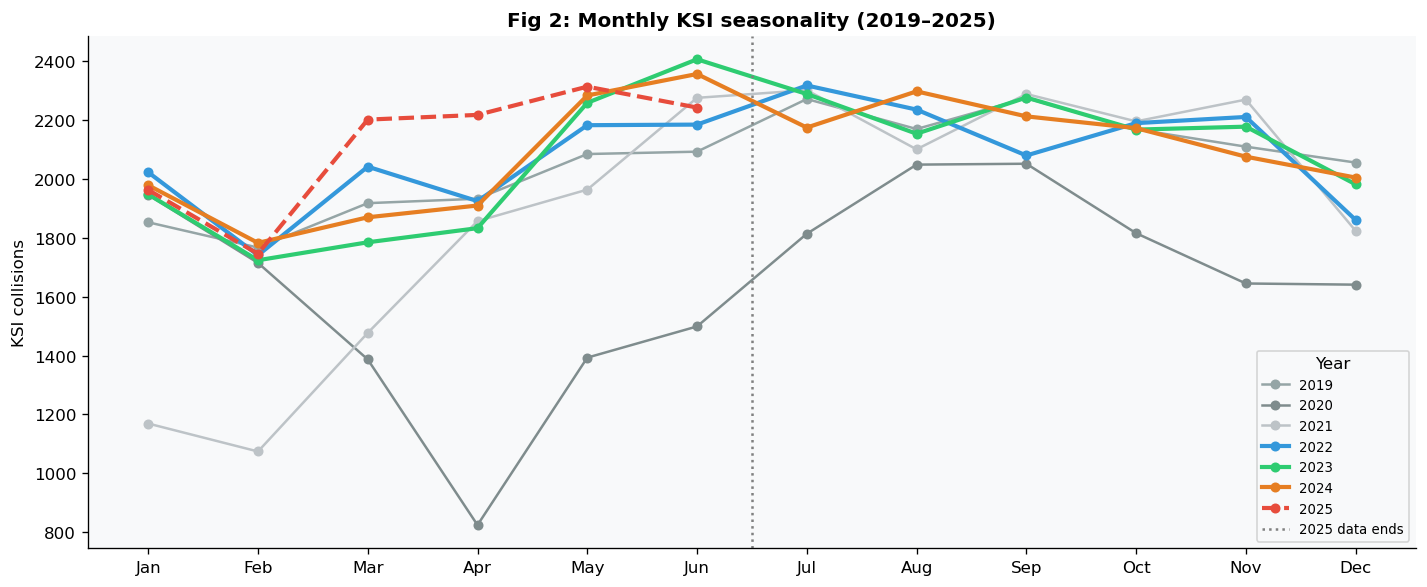

Saved: C:\Users\u2211111\outputs\fig_02_seasonality.png
Average H1 share (excl. COVID): 48.0%
2025 Jan–Jun KSI              : 12,686
2025 annualised estimate      : 26,446  (provisional — treat with caution)


<Figure size 768x576 with 0 Axes>

In [12]:
# 3.1 Seasonality check — validate 2025 annualisation
RECENT = [2019,2020,2021,2022,2023,2024,2025]
monthly = (col[col['collision_year'].isin(RECENT) & col['ksi']]
           .groupby(['collision_year','month']).size().reset_index(name='ksi_count'))
share = []
for yr in [2019,2020,2021,2022,2023,2024]:
    d  = monthly[monthly['collision_year']==yr]
    h1 = d[d['month']<=6]['ksi_count'].sum()
    share.append({'year':yr,'h1_pct':h1/d['ksi_count'].sum()*100})
share_df = pd.DataFrame(share)

fig, ax = plt.subplots(figsize=(12,5))
colors = ['#95a5a6','#7f8c8d','#bdc3c7','#3498db','#2ecc71','#e67e22','#e74c3c']
for i, yr in enumerate(RECENT):
    d = monthly[monthly['collision_year']==yr]
    ax.plot(d['month'], d['ksi_count'], marker='o', label=str(yr), color=colors[i],
            linestyle='--' if yr==2025 else '-',
            linewidth=2.5 if yr>=2022 else 1.5, markersize=5)
ax.axvline(6.5, color='grey', linestyle=':', linewidth=1.5, label='2025 data ends')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Fig 2: Monthly KSI seasonality (2019–2025)', fontweight='bold')
ax.set_ylabel('KSI collisions')
ax.legend(title='Year', fontsize=8)
plt.tight_layout(); plt.show(); savefig('fig_02_seasonality')

clean      = share_df[~share_df['year'].isin(COVID_YEARS)]
ann_factor = 100/clean['h1_pct'].mean()
ksi_h1     = monthly[monthly['collision_year']==2025]['ksi_count'].sum()
ksi_ann    = ksi_h1 * ann_factor
print(f'Average H1 share (excl. COVID): {clean["h1_pct"].mean():.1f}%')
print(f'2025 Jan–Jun KSI              : {ksi_h1:,}')
print(f'2025 annualised estimate      : {ksi_ann:,.0f}  (provisional — treat with caution)')


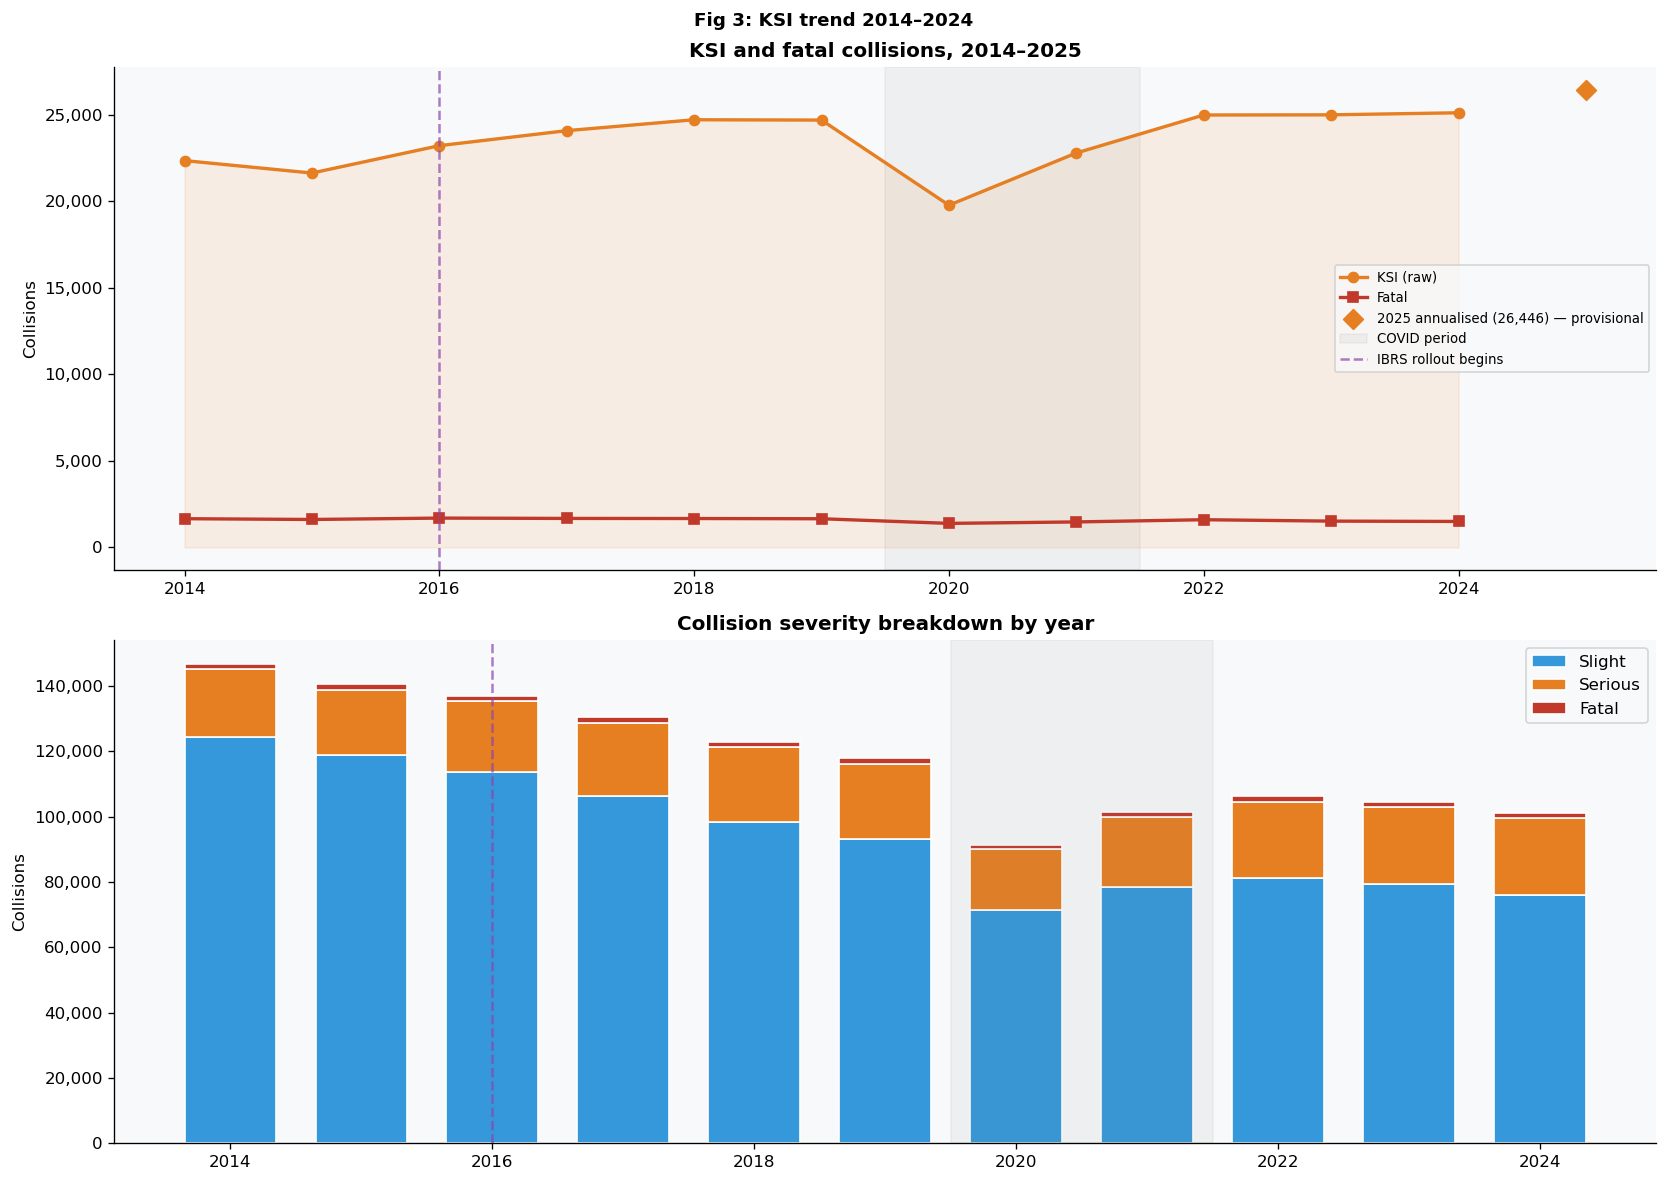

Saved: C:\Users\u2211111\outputs\fig_03_ksi_trend.png


<Figure size 768x576 with 0 Axes>

In [13]:
# 3.2 Long-term KSI trend
annual = (col[col['collision_year']<=2024]
          .groupby('collision_year')
          .agg(collisions=('collision_index','nunique'), ksi=('ksi','sum'), fatals=('fatal','sum'))
          .reset_index())

fig, axes = plt.subplots(2,1,figsize=(14,10))
ax = axes[0]
ax.fill_between(annual['collision_year'], annual['ksi'], alpha=0.10, color='#e67e22')
ax.plot(annual['collision_year'], annual['ksi'],    color='#e67e22', lw=2, marker='o', label='KSI (raw)')
ax.plot(annual['collision_year'], annual['fatals'], color='#c0392b', lw=2, marker='s', label='Fatal')
ax.scatter([2025],[ksi_ann], color='#e67e22', marker='D', s=70, zorder=5,
           label=f'2025 annualised ({ksi_ann:,.0f}) — provisional')
ax.axvspan(2019.5,2021.5, alpha=0.08, color='grey', label='COVID period')
ax.axvline(2016, color='#8e44ad', lw=1.5, linestyle='--', alpha=0.7, label='IBRS rollout begins')
ax.set_title('KSI and fatal collisions, 2014–2025', fontweight='bold')
ax.set_ylabel('Collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=8)

ax2 = axes[1]
by_sev = (col[col['collision_year'].between(2014,2024)]
          .groupby(['collision_year','collision_severity']).size().unstack(fill_value=0)
          .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
bottom = np.zeros(len(by_sev))
for sev, color in [('Slight','#3498db'),('Serious','#e67e22'),('Fatal','#c0392b')]:
    if sev in by_sev.columns:
        ax2.bar(by_sev.index, by_sev[sev], bottom=bottom, color=color, label=sev, edgecolor='white', width=0.7)
        bottom += by_sev[sev].values
ax2.axvspan(2019.5,2021.5, alpha=0.08, color='grey')
ax2.axvline(2016, color='#8e44ad', lw=1.5, linestyle='--', alpha=0.7)
ax2.set_title('Collision severity breakdown by year', fontweight='bold')
ax2.set_ylabel('Collisions')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax2.legend()
plt.suptitle('Fig 3: KSI trend 2014–2024', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show(); savefig('fig_03_ksi_trend')


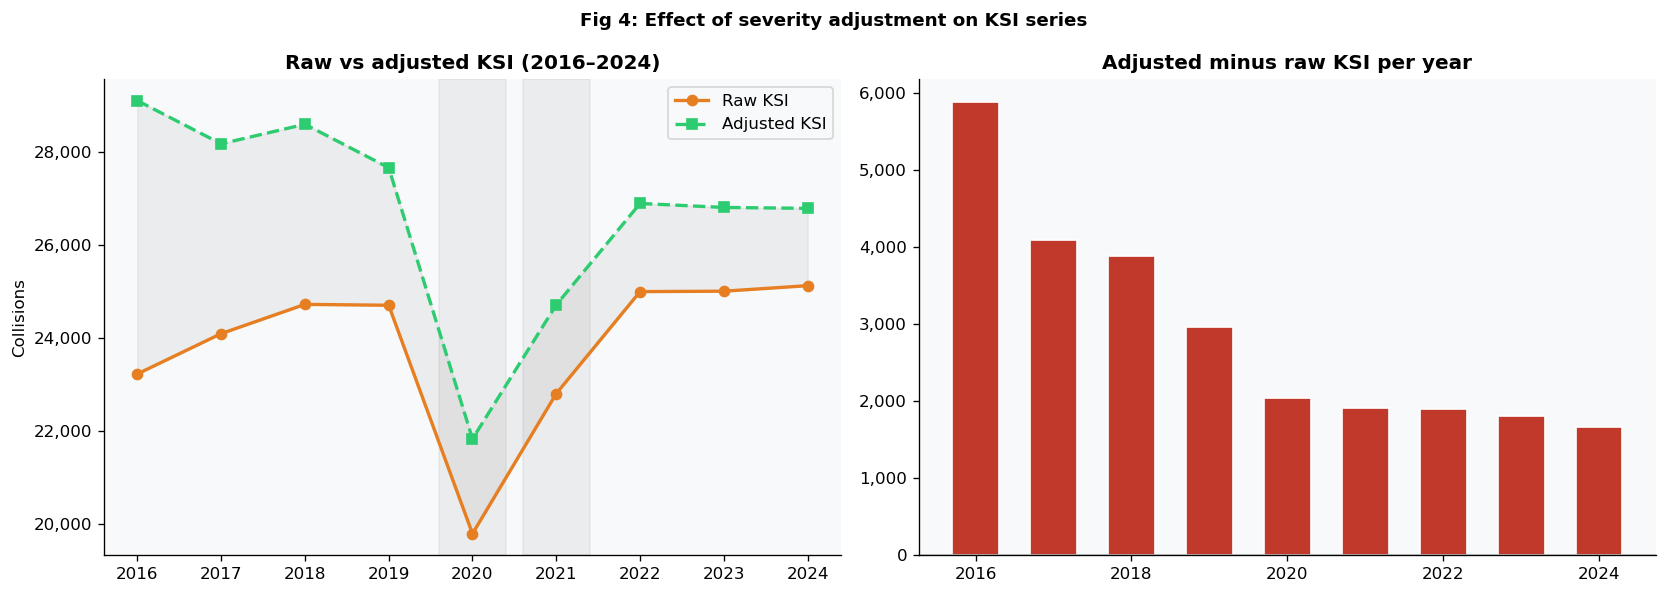

Saved: C:\Users\u2211111\outputs\fig_04_raw_vs_adjusted.png
 collision_year  raw_ksi      adj_ksi  ibrs_pct
           2016    23222 29108.430432      31.2
           2017    24090 28178.597669      35.6
           2018    24720 28599.768234      35.2
           2019    24701 27663.544498      42.3
           2020    19781 21823.632978      45.0
           2021    22799 24710.214204      49.7
           2022    24995 26893.958525      52.6
           2023    25004 26808.394853      53.8
           2024    25123 26788.669491      58.8


<Figure size 768x576 with 0 Axes>

In [14]:
# 3.3 Raw vs IBRS-adjusted KSI
ibrs_w = col[(col['collision_year']>=2016) & (col['collision_year']<=2024) & (~col['provisional'])].copy()
adj = ibrs_w.groupby('collision_year').agg(
    raw_fatal   = ('fatal','sum'),
    raw_serious = ('collision_severity', lambda x: (x==2).sum()),
    adj_serious = ('collision_adjusted_severity_serious','sum'),
    ibrs_pct    = ('collision_injury_based', lambda x: (x==1).sum()/len(x)*100)
).reset_index()
adj['raw_ksi'] = adj['raw_fatal'] + adj['raw_serious']
adj['adj_ksi'] = adj['raw_fatal'] + adj['adj_serious']
adj['ibrs_pct'] = adj['ibrs_pct'].round(1)

fig, axes = plt.subplots(1,2,figsize=(14,5))
ax = axes[0]
ax.plot(adj['collision_year'], adj['raw_ksi'], marker='o', color='#e67e22', lw=2, label='Raw KSI')
ax.plot(adj['collision_year'], adj['adj_ksi'], marker='s', color='#2ecc71', lw=2,
        linestyle='--', label='Adjusted KSI')
ax.fill_between(adj['collision_year'], adj['raw_ksi'], adj['adj_ksi'], alpha=0.1, color='grey')
for yr in COVID_YEARS:
    ax.axvspan(yr-0.4,yr+0.4, alpha=0.1, color='grey')
ax.set_title('Raw vs adjusted KSI (2016–2024)', fontweight='bold')
ax.set_ylabel('Collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()

ax2 = axes[1]
gap = adj['adj_ksi'] - adj['raw_ksi']
ax2.bar(adj['collision_year'], gap,
        color=['#c0392b' if d>0 else '#2ecc71' for d in gap], width=0.6, edgecolor='white')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Adjusted minus raw KSI per year', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.suptitle('Fig 4: Effect of severity adjustment on KSI series', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show(); savefig('fig_04_raw_vs_adjusted')

adj[['collision_year','raw_serious','adj_serious','raw_ksi','adj_ksi','ibrs_pct']].to_csv(
    os.path.join(OUTPUT_DIR,'tab_raw_vs_adjusted_ksi.csv'), index=False)
print(adj[['collision_year','raw_ksi','adj_ksi','ibrs_pct']].to_string(index=False))


---
## 4. Road User Severity Profile (2016–2024)

Uses 2016–2024 to align with the IBRS period. Analysis at casualty level —
one seriously injured person in a collision with three casualties counts as one.
`casualty_type = 0` (not in STATS19 codebook) treated as Unknown throughout.


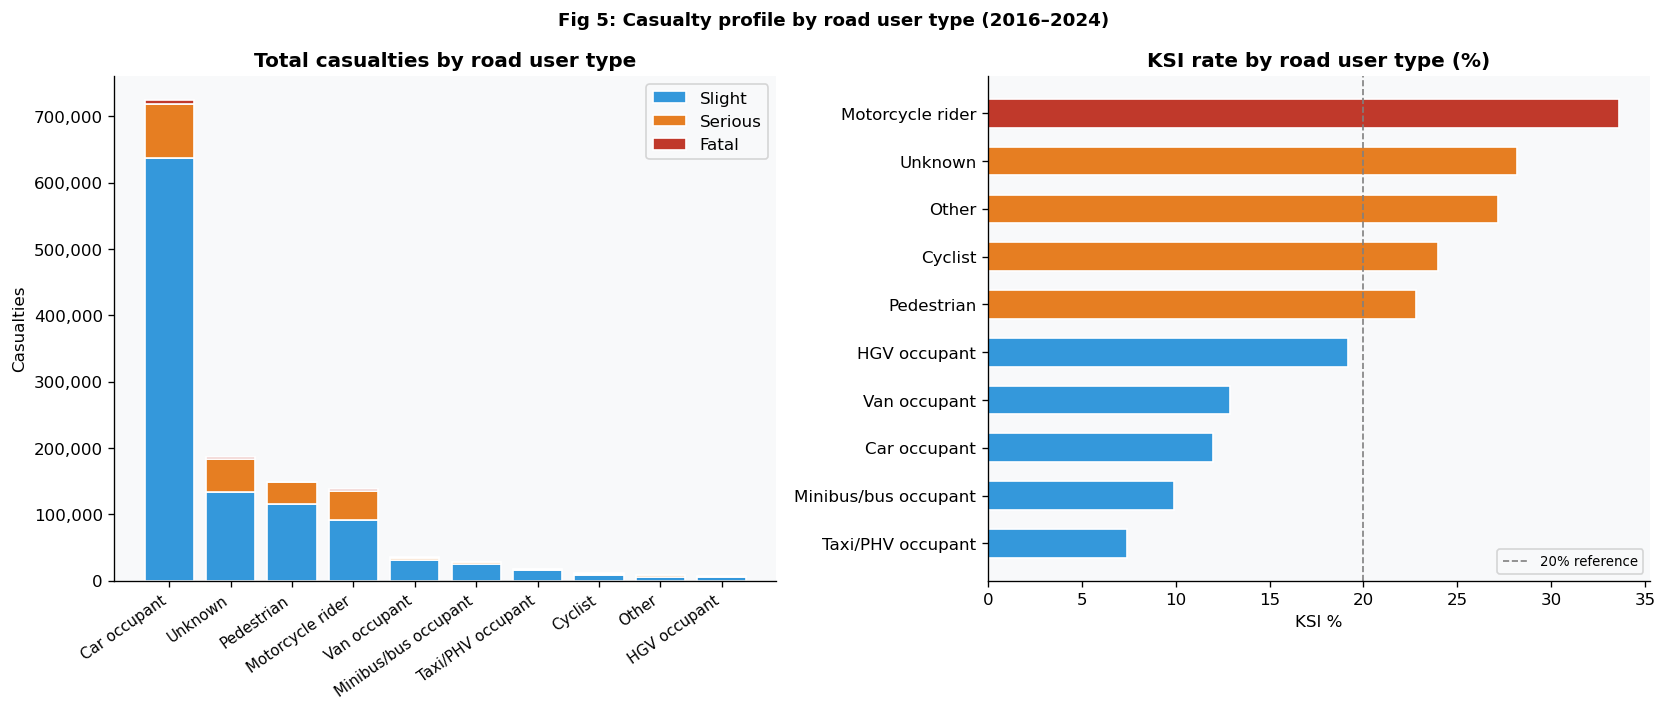

Saved: C:\Users\u2211111\outputs\fig_05_road_user_severity.png
casualty_severity     Fatal  Serious  Slight   Total    KSI  KSI%  Fatal%
road_user                                                                
Car occupant           6516    80772  637360  724648  87288  12.0    0.90
Unknown                3796    49002  134345  187143  52798  28.2    2.03
Pedestrian              914    33050  115260  149224  33964  22.8    0.61
Motorcycle rider       2915    43744   92160  138819  46659  33.6    2.10
Van occupant            361     4172   30558   35091   4533  12.9    1.03
Minibus/bus occupant     85     2644   24837   27566   2729   9.9    0.31
Taxi/PHV occupant        77     1242   16612   17931   1319   7.4    0.43
Cyclist                  43     2568    8274   10885   2611  24.0    0.40
Other                   213     2005    5933    8151   2218  27.2    2.61
HGV occupant            156     1229    5811    7196   1385  19.2    2.17


<Figure size 768x576 with 0 Axes>

In [15]:
prov_map = col.drop_duplicates('collision_index').set_index('collision_index')['provisional']
cas_w = cas.copy()
cas_w['provisional'] = cas_w['collision_index'].map(prov_map).fillna(False)
window = cas_w[(cas_w['collision_year']>=2016) & (cas_w['collision_year']<=2024) & (~cas_w['provisional'])].copy()

ru = window.groupby('road_user')['casualty_severity'].value_counts().unstack(fill_value=0)
ru = ru.rename(columns={1:'Fatal',2:'Serious',3:'Slight'})
for c in ['Fatal','Serious','Slight']:
    if c not in ru.columns: ru[c] = 0
ru['Total'] = ru['Fatal']+ru['Serious']+ru['Slight']
ru['KSI']   = ru['Fatal']+ru['Serious']
ru['KSI%']  = (ru['KSI']/ru['Total']*100).round(1)
ru['Fatal%'] = (ru['Fatal']/ru['Total']*100).round(2)
ru = ru.sort_values('Total', ascending=False)

fig, axes = plt.subplots(1,2,figsize=(14,6))
ax = axes[0]
top = ru[ru['Total']>1000].copy()
bottom = np.zeros(len(top))
for sev, color in [('Slight','#3498db'),('Serious','#e67e22'),('Fatal','#c0392b')]:
    ax.bar(range(len(top)), top[sev], bottom=bottom, color=color, label=sev, edgecolor='white')
    bottom += top[sev].values
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=35, ha='right', fontsize=9)
ax.set_title('Total casualties by road user type', fontweight='bold')
ax.set_ylabel('Casualties')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()

ax2 = axes[1]
ksi_plot = ru[ru['Total']>1000].sort_values('KSI%', ascending=True)
bar_colors = ['#c0392b' if k>30 else '#e67e22' if k>20 else '#3498db' for k in ksi_plot['KSI%']]
ax2.barh(ksi_plot.index, ksi_plot['KSI%'], color=bar_colors, edgecolor='white', height=0.6)
ax2.axvline(20, color='grey', linestyle='--', lw=1, label='20% reference')
ax2.set_title('KSI rate by road user type (%)', fontweight='bold')
ax2.set_xlabel('KSI %')
ax2.legend(fontsize=8)
plt.suptitle('Fig 5: Casualty profile by road user type (2016–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show(); savefig('fig_05_road_user_severity')

ru[['Fatal','Serious','Slight','Total','KSI','KSI%','Fatal%']].to_csv(
    os.path.join(OUTPUT_DIR,'tab_road_user_severity.csv'))
print(ru[['Fatal','Serious','Slight','Total','KSI','KSI%','Fatal%']].to_string())


---
## 5. Geographic Hotspot Analysis (2022–2024)

Two hotspot definitions compared: raw KSI count and KSI rate per collision.
The count definition identifies areas with high road exposure; the rate
definition identifies areas where collisions are most likely to result in
serious injury. Both are shown because they imply different intervention strategies.


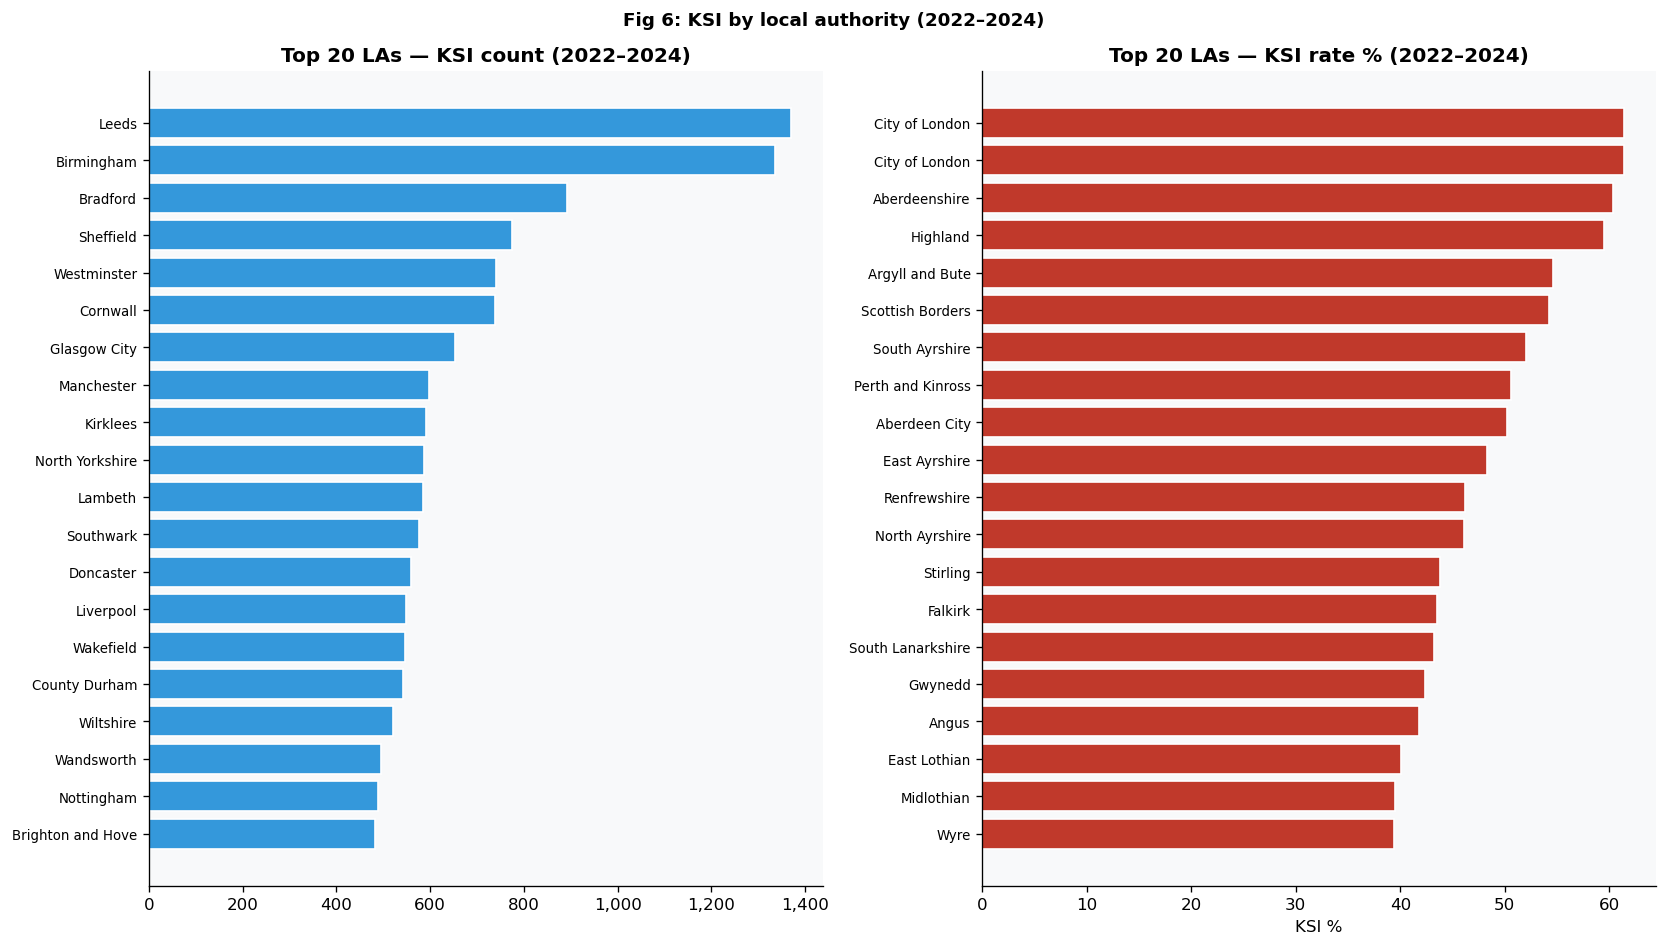

Saved: C:\Users\u2211111\outputs\fig_06_la_hotspots.png


<Figure size 768x576 with 0 Axes>

In [16]:
hot = col[(col['collision_year']>=2022) & (col['collision_year']<=2024)].copy()

la = hot.groupby('local_authority_ons_district').agg(
    collisions=('collision_index','nunique'), ksi=('ksi','sum'), fatals=('fatal','sum')
).reset_index()
la['ksi_pct']   = (la['ksi']/la['collisions']*100).round(1)
la['fatal_pct'] = (la['fatals']/la['collisions']*100).round(2)
la = la.merge(la_lookup, on='local_authority_ons_district', how='left')
la['la_name'] = la['la_name'].fillna(la['local_authority_ons_district'])
la = la.sort_values('ksi', ascending=False)

fig, axes = plt.subplots(1,2,figsize=(14,8))
top20 = la.head(20).sort_values('ksi')
axes[0].barh(range(len(top20)), top20['ksi'], color='#3498db', edgecolor='white')
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['la_name'], fontsize=8)
axes[0].set_title('Top 20 LAs — KSI count (2022–2024)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

la_rate = la[la['collisions']>200].sort_values('ksi_pct', ascending=False).head(20).sort_values('ksi_pct')
axes[1].barh(range(len(la_rate)), la_rate['ksi_pct'], color='#c0392b', edgecolor='white')
axes[1].set_yticks(range(len(la_rate)))
axes[1].set_yticklabels(la_rate['la_name'], fontsize=8)
axes[1].set_title('Top 20 LAs — KSI rate % (2022–2024)', fontweight='bold')
axes[1].set_xlabel('KSI %')

plt.suptitle('Fig 6: KSI by local authority (2022–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show(); savefig('fig_06_la_hotspots')
la.to_csv(os.path.join(OUTPUT_DIR,'tab_la_hotspots.csv'), index=False)


---
## 6. Contributory Factors (2022–2024)

Four factors examined: urban/rural setting, speed limit, road type, junction type.
Both count and rate shown throughout — count reflects exposure, rate reflects risk.


In [17]:
ur = (hot.groupby('ur_label')['collision_severity']
      .value_counts().unstack(fill_value=0)
      .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in ur.columns: ur[c] = 0
ur['Total']  = ur['Fatal']+ur['Serious']+ur['Slight']
ur['KSI']    = ur['Fatal']+ur['Serious']
ur['KSI%']   = (ur['KSI']/ur['Total']*100).round(1)
ur['Fatal%'] = (ur['Fatal']/ur['Total']*100).round(2)
print('Urban vs Rural KSI breakdown (2022–2024):')
display(ur[['Fatal','Serious','Slight','Total','KSI','KSI%','Fatal%']])
ur[['Fatal','Serious','Slight','Total','KSI','KSI%','Fatal%']].to_csv(
    os.path.join(OUTPUT_DIR,'tab_urban_rural.csv'))


Urban vs Rural KSI breakdown (2022–2024):


collision_severity,Fatal,Serious,Slight,Total,KSI,KSI%,Fatal%
ur_label,,,,,,,
Rural,2924,26836,72021,101781,29760,29.2,2.87
Unallocated,0,8,21,29,8,27.6,0.00
Urban,1704,43648,164534,209886,45352,21.6,0.81


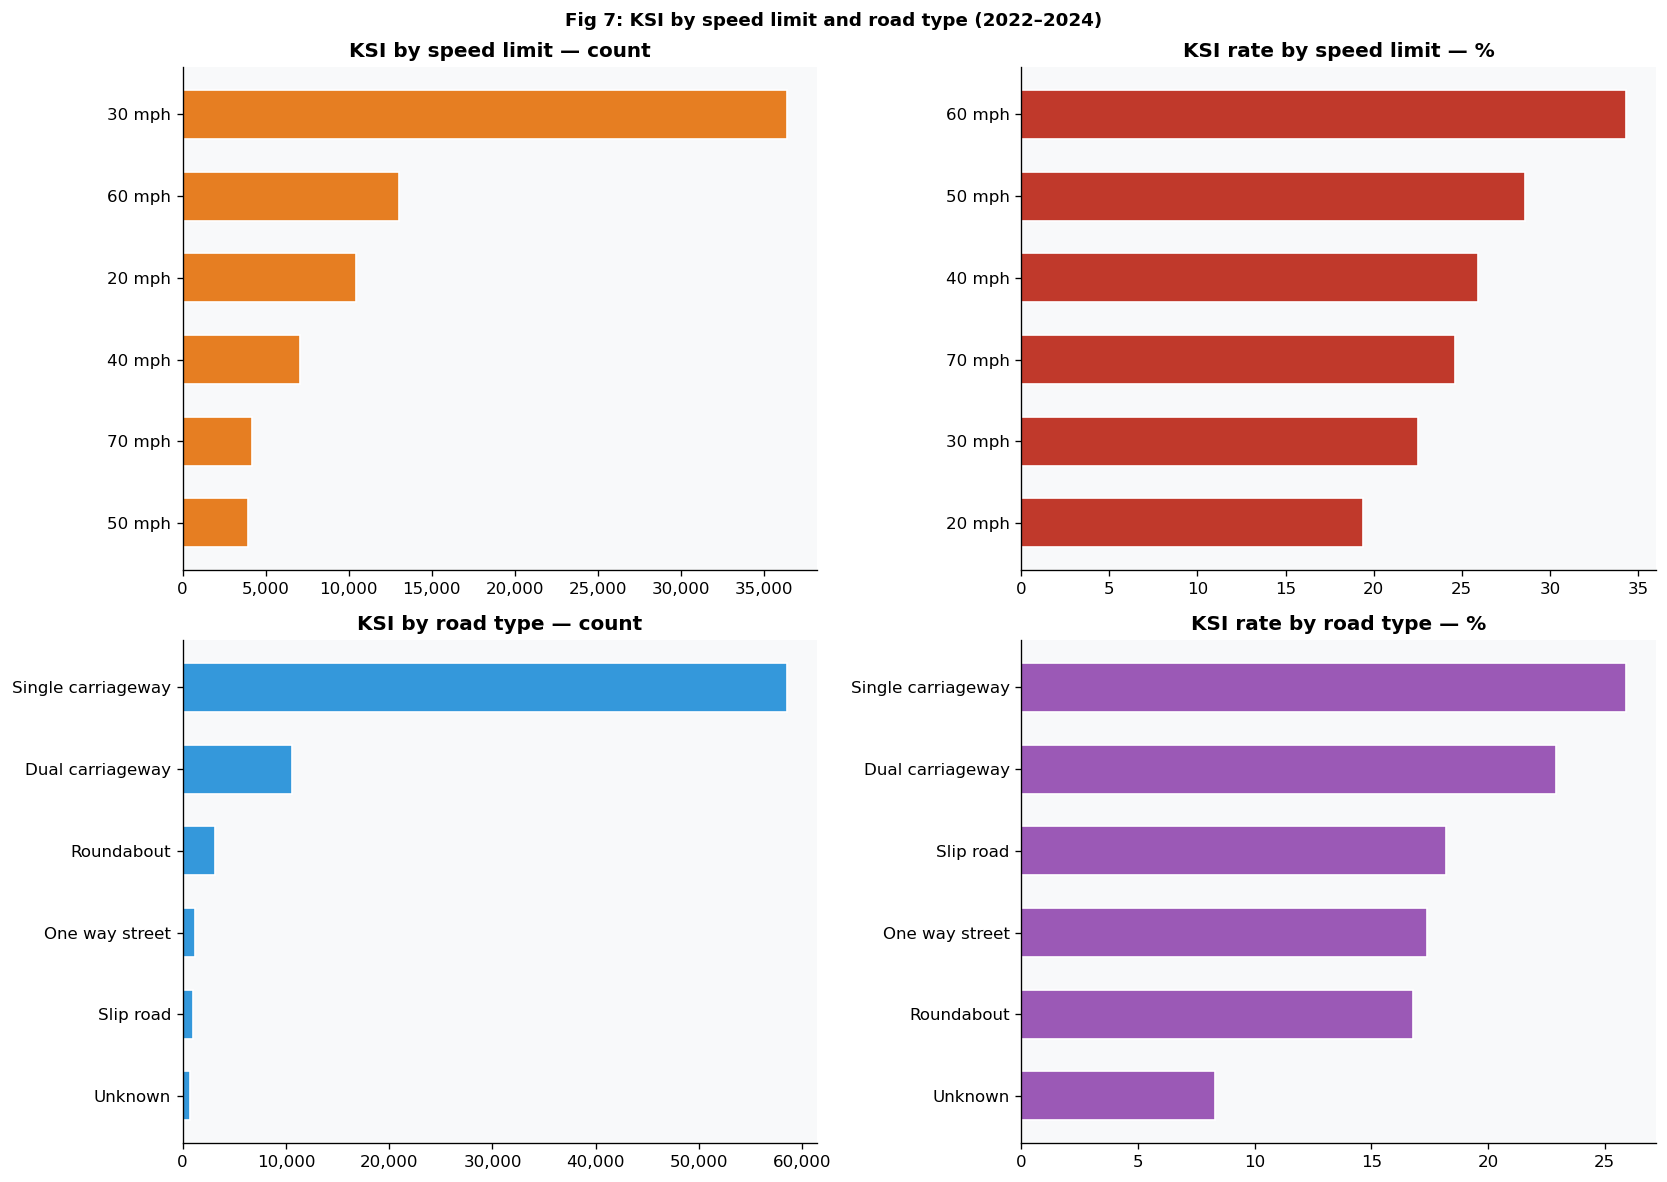

Saved: C:\Users\u2211111\outputs\fig_07_speed_road_type.png


<Figure size 768x576 with 0 Axes>

In [18]:
fig, axes = plt.subplots(2,2,figsize=(14,10))

speed = (hot[hot['speed_limit'].notna()]
         .groupby('speed_limit')['collision_severity']
         .value_counts().unstack(fill_value=0)
         .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in speed.columns: speed[c] = 0
speed['KSI']   = speed['Fatal']+speed['Serious']
speed['Total'] = speed['Fatal']+speed['Serious']+speed['Slight']
speed['KSI%']  = (speed['KSI']/speed['Total']*100).round(1)

s = speed.sort_values('KSI', ascending=True)
axes[0,0].barh([f'{int(x)} mph' for x in s.index], s['KSI'], color='#e67e22', edgecolor='white', height=0.6)
axes[0,0].set_title('KSI by speed limit — count', fontweight='bold')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

sr = speed.sort_values('KSI%', ascending=True)
axes[0,1].barh([f'{int(x)} mph' for x in sr.index], sr['KSI%'], color='#c0392b', edgecolor='white', height=0.6)
axes[0,1].set_title('KSI rate by speed limit — %', fontweight='bold')

rc = (hot[hot['road_type_label'].notna()]
      .groupby('road_type_label')['collision_severity']
      .value_counts().unstack(fill_value=0)
      .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in rc.columns: rc[c] = 0
rc['KSI']   = rc['Fatal']+rc['Serious']
rc['Total'] = rc['Fatal']+rc['Serious']+rc['Slight']
rc['KSI%']  = (rc['KSI']/rc['Total']*100).round(1)

r = rc.sort_values('KSI', ascending=True)
axes[1,0].barh(r.index, r['KSI'], color='#3498db', edgecolor='white', height=0.6)
axes[1,0].set_title('KSI by road type — count', fontweight='bold')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

rr = rc.sort_values('KSI%', ascending=True)
axes[1,1].barh(rr.index, rr['KSI%'], color='#9b59b6', edgecolor='white', height=0.6)
axes[1,1].set_title('KSI rate by road type — %', fontweight='bold')

plt.suptitle('Fig 7: KSI by speed limit and road type (2022–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show(); savefig('fig_07_speed_road_type')


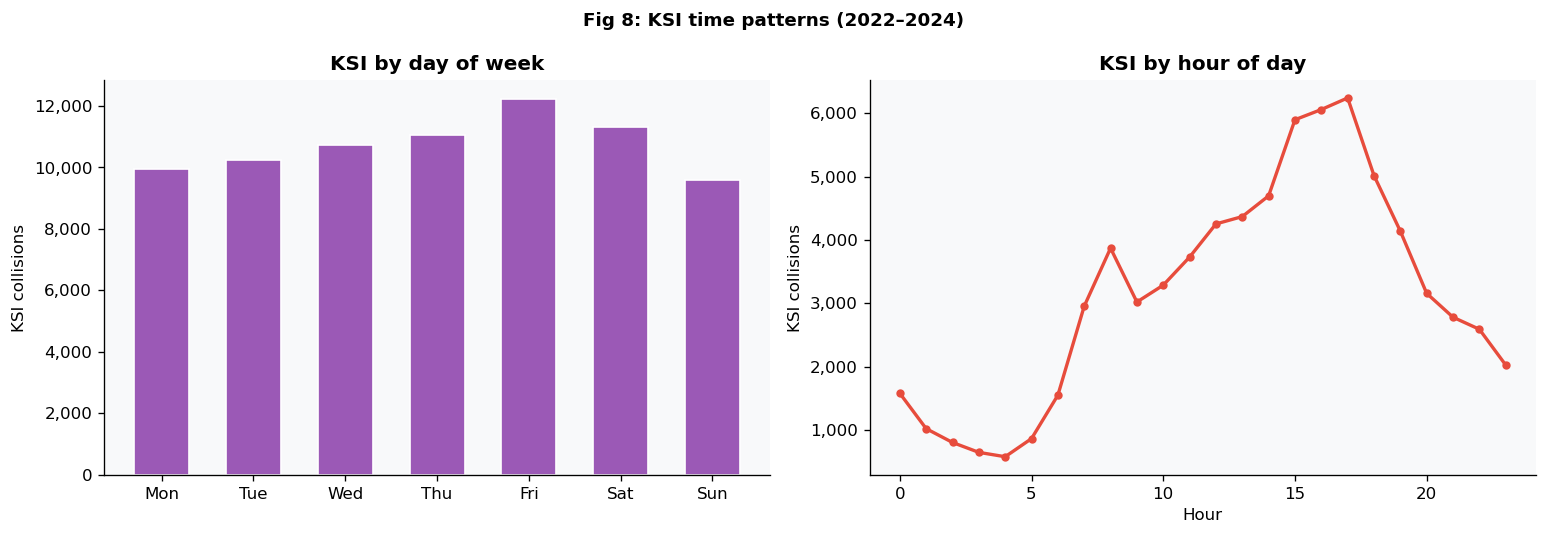

Saved: C:\Users\u2211111\outputs\fig_08_time_patterns.png


<Figure size 768x576 with 0 Axes>

In [19]:
fig, axes = plt.subplots(1,2,figsize=(13,4.5))
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day = (hot[hot['day_label'].notna() & hot['ksi']].groupby('day_label').size().reindex(day_order))
axes[0].bar(day.index, day.values, color='#9b59b6', edgecolor='white', width=0.6)
axes[0].set_title('KSI by day of week', fontweight='bold')
axes[0].set_ylabel('KSI collisions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

hot_h = hot[hot['ksi']].copy()
hot_h['hour'] = pd.to_datetime(hot_h['time'], format='%H:%M', errors='coerce').dt.hour
hour = hot_h.groupby('hour').size()
axes[1].plot(hour.index, hour.values, color='#e74c3c', lw=2, marker='o', markersize=4)
axes[1].set_title('KSI by hour of day', fontweight='bold')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('KSI collisions')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Fig 8: KSI time patterns (2022–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show(); savefig('fig_08_time_patterns')


---
## 7. Local Authority Trend Analysis (2014–2024)

OLS regression of annual KSI casualty count on year fitted per LA.
53 LAs excluded due to boundary reorganisations (e.g. North Yorkshire 2023 restructuring).
Dual method check: OLS slope vs 3-year average comparison.


In [20]:
cas_full = pd.read_csv(CAS_FULL, dtype={'collision_index':str}, low_memory=False)
ksi = cas_full[
    cas_full['ksi'].eq(True) &
    cas_full['provisional'].eq(False) &
    cas_full['la_name'].notna()
].copy()
print(f'KSI casualties loaded: {len(ksi):,}')
print(f'Years: {sorted(ksi["collision_year"].dropna().unique().astype(int).tolist())}')


KSI casualties loaded: 300,776
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [21]:
def complete_las(df, years):
    return set(
        df[df['collision_year'].isin(years)]
        .groupby('la_name')['collision_year'].nunique()
        .pipe(lambda s: s[s==len(years)].index)
    )

complete     = complete_las(ksi, BASE_YEARS) & complete_las(ksi, RECENT_YEARS)
ksi_complete = ksi[ksi['la_name'].isin(complete)].copy()
print(f'LAs with complete data : {len(complete)}')
print(f'LAs excluded           : {ksi["la_name"].nunique() - len(complete)}')

annual = (ksi_complete.groupby(['la_name','collision_year'])
          .size().reset_index(name='KSI'))


LAs with complete data : 339
LAs excluded           : 53


In [22]:
# OLS per LA with 95% confidence intervals
ols_rows = []
for la, grp in annual.groupby('la_name'):
    grp = grp.dropna(subset=['KSI','collision_year'])
    if len(grp) < MIN_YEARS:
        continue
    x = grp['collision_year'].values
    y = grp['KSI'].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    # 95% CI on slope
    t_crit = stats.t.ppf(0.975, df=len(x)-2)
    ci_lower = slope - t_crit * se
    ci_upper = slope + t_crit * se
    ols_rows.append({
        'la_name'   : la,
        'slope'     : slope,
        'ci_lower'  : ci_lower,
        'ci_upper'  : ci_upper,
        'se'        : se,
        'intercept' : intercept,
        'r_squared' : r**2,
        'p_value'   : p,
        'n_years'   : len(grp),
        'mean_ksi'  : y.mean(),
    })

ols = pd.DataFrame(ols_rows)
ols = ols[ols['mean_ksi'] >= MIN_KSI_BASE].copy()
ols['trend_shape'] = ols['r_squared'].apply(lambda r: 'Linear' if r>=LOW_R2 else 'Non-linear')
ols['ci_includes_zero'] = (ols['ci_lower'] < 0) & (ols['ci_upper'] > 0)

# 3-year average secondary check
def window_avg(df, years):
    return (df[df['collision_year'].isin(years)].groupby('la_name')
            .size().div(len(years)).reset_index(name='ksi_avg'))

base   = window_avg(ksi_complete, BASE_YEARS).rename(columns={'ksi_avg':'base_avg'})
recent = window_avg(ksi_complete, RECENT_YEARS).rename(columns={'ksi_avg':'recent_avg'})
avg_chg = base.merge(recent, on='la_name')
avg_chg['avg_pct_change'] = (avg_chg['recent_avg']-avg_chg['base_avg'])/avg_chg['base_avg']*100
ols = ols.merge(avg_chg[['la_name','base_avg','recent_avg','avg_pct_change']], on='la_name', how='left')
ols['methods_agree'] = (ols['slope']>0) == (ols['avg_pct_change']>0)

print(f'LAs fitted           : {len(ols)}')
print(f'Linear (R² >= {LOW_R2}): {(ols["r_squared"]>=LOW_R2).sum()}')
print(f'CI includes zero     : {ols["ci_includes_zero"].sum()} LAs (slope not stat. significant)')
print(f'Methods agree        : {ols["methods_agree"].sum()} / {len(ols)}')

ols.to_csv(os.path.join(OUTPUT_DIR,'tab_la_ols_results.csv'), index=False)


LAs fitted           : 308
Linear (R² >= 0.5): 39
CI includes zero     : 238 LAs (slope not stat. significant)
Methods agree        : 278 / 308


In [23]:
# Worsening LAs
worsening = ols[ols['slope']>0].sort_values('slope', ascending=False).reset_index(drop=True)
worsening['rank'] = worsening.index + 1
top5_w = worsening.head(TOP_N)
top5_w_names = top5_w['la_name'].tolist()
top3_w_names = top5_w_names[:TOP_N_LINES]

print('=== Top 5 worsening LAs ===')
print(top5_w[['rank','la_name','slope','ci_lower','ci_upper','r_squared','p_value',
              'trend_shape','avg_pct_change','ci_includes_zero']].round(3).to_string(index=False))


=== Top 5 worsening LAs ===
 rank   la_name  slope  ci_lower  ci_upper  r_squared  p_value trend_shape  avg_pct_change  ci_includes_zero
    1     Leeds 20.336     1.693    38.980      0.404    0.036  Non-linear          57.890             False
    2  Bradford 19.418     8.052    30.785      0.624    0.004      Linear          87.279             False
    3 Southwark 13.827     9.194    18.460      0.835    0.000      Linear          99.645             False
    4  Highland 12.573     7.901    17.244      0.805    0.000      Linear         101.014             False
    5   Lambeth 11.000     3.493    18.507      0.550    0.009      Linear          49.377             False


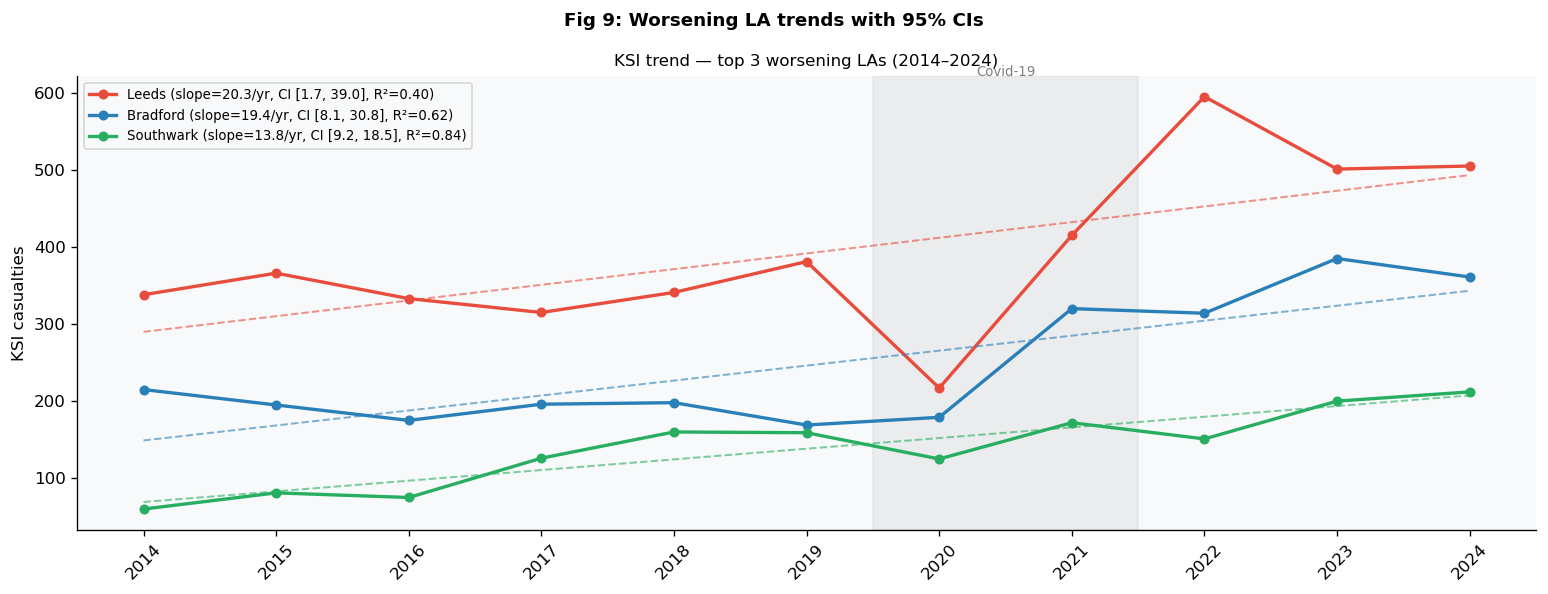

Saved: C:\Users\u2211111\outputs\fig_09_worsening_las.png


<Figure size 768x576 with 0 Axes>

In [24]:
years_range = np.array(sorted(ksi_complete['collision_year'].unique()))
palette     = ['#e74c3c','#2980b9','#27ae60']
la_colors_w = dict(zip(top3_w_names, palette))

fig, ax = plt.subplots(figsize=(13,5))
ax.axvspan(2019.5,2021.5, alpha=0.10, color='grey')
ax.text(2020.5, 1, 'Covid-19', ha='center', fontsize=8, color='grey',
        transform=ax.get_xaxis_transform())
for la in top3_w_names:
    sub = annual[annual['la_name']==la]
    row = ols[ols['la_name']==la].iloc[0]
    c   = la_colors_w[la]
    ci_str = f'CI [{row["ci_lower"]:.1f}, {row["ci_upper"]:.1f}]'
    ax.plot(sub['collision_year'], sub['KSI'], color=c, lw=2, marker='o', ms=5,
            label=f"{la} (slope={row['slope']:.1f}/yr, {ci_str}, R²={row['r_squared']:.2f})")
    ax.plot(years_range, row['intercept']+row['slope']*years_range,
            color=c, lw=1.2, linestyle='--', alpha=0.6)
ax.set_title('KSI trend — top 3 worsening LAs (2014–2024)', fontsize=10)
ax.set_ylabel('KSI casualties')
ax.set_xticks(range(2014,2025)); ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=8)
plt.suptitle('Fig 9: Worsening LA trends with 95% CIs', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show(); savefig('fig_09_worsening_las')


=== Top 5 improving LAs ===
 rank                   la_name   slope  ci_lower  ci_upper  r_squared  p_value trend_shape  avg_pct_change  ci_includes_zero
    1                 Liverpool -10.091   -17.522    -2.660      0.512    0.013      Linear         -22.254             False
    2                 Wiltshire  -7.764   -18.638     3.111      0.225    0.141  Non-linear         -14.655              True
    3             Cheshire East  -7.536   -14.588    -0.485      0.394    0.039  Non-linear         -18.056             False
    4             Milton Keynes  -7.536   -10.688    -4.385      0.765    0.000      Linear         -44.348             False
    5 Cheshire West and Chester  -7.527   -13.518    -1.536      0.473    0.019  Non-linear         -27.629             False


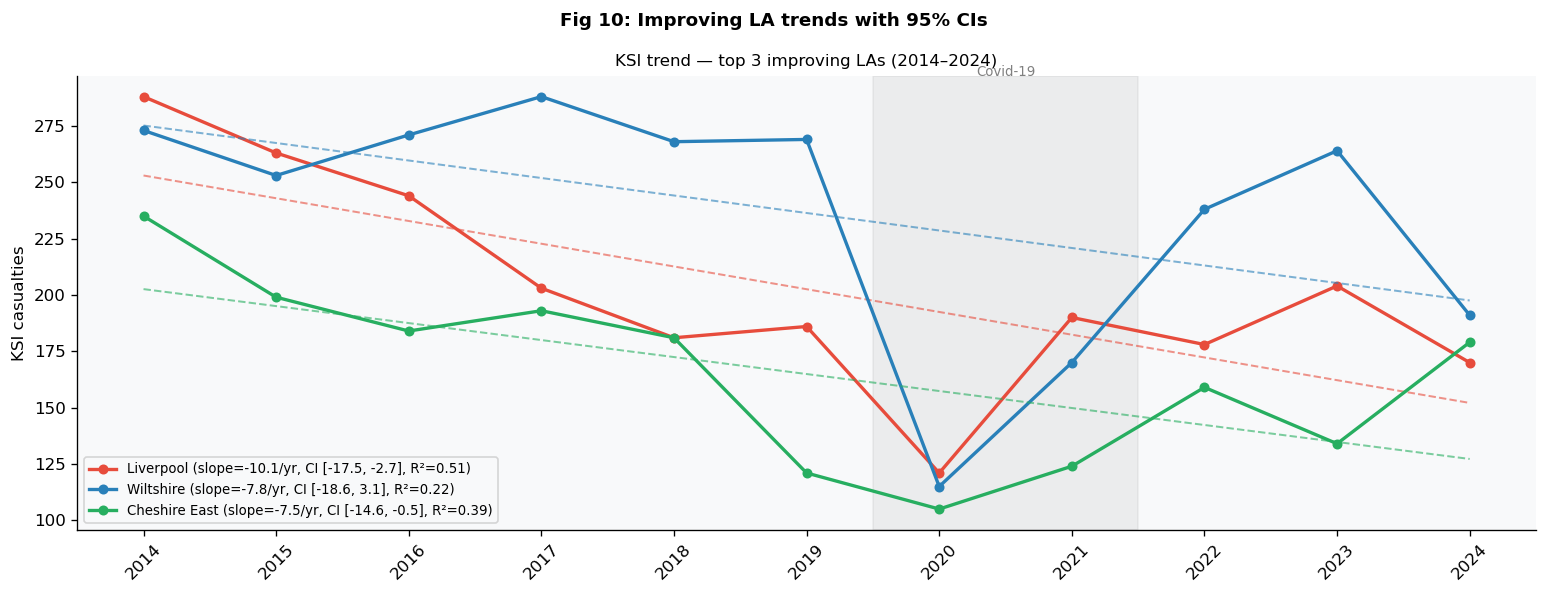

Saved: C:\Users\u2211111\outputs\fig_10_improving_las.png


<Figure size 768x576 with 0 Axes>

In [25]:
# Improving LAs
improving = ols[ols['slope']<0].sort_values('slope').reset_index(drop=True)
improving['rank'] = improving.index + 1
top5_i = improving.head(TOP_N)
top5_i_names = top5_i['la_name'].tolist()
top3_i_names = top5_i_names[:TOP_N_LINES]

print('=== Top 5 improving LAs ===')
print(top5_i[['rank','la_name','slope','ci_lower','ci_upper','r_squared','p_value',
              'trend_shape','avg_pct_change','ci_includes_zero']].round(3).to_string(index=False))

la_colors_i = dict(zip(top3_i_names, palette))
fig, ax = plt.subplots(figsize=(13,5))
ax.axvspan(2019.5,2021.5, alpha=0.10, color='grey')
ax.text(2020.5, 1, 'Covid-19', ha='center', fontsize=8, color='grey',
        transform=ax.get_xaxis_transform())
for la in top3_i_names:
    sub = annual[annual['la_name']==la]
    row = ols[ols['la_name']==la].iloc[0]
    c   = la_colors_i[la]
    ci_str = f'CI [{row["ci_lower"]:.1f}, {row["ci_upper"]:.1f}]'
    ax.plot(sub['collision_year'], sub['KSI'], color=c, lw=2, marker='o', ms=5,
            label=f"{la} (slope={row['slope']:.1f}/yr, {ci_str}, R²={row['r_squared']:.2f})")
    ax.plot(years_range, row['intercept']+row['slope']*years_range,
            color=c, lw=1.2, linestyle='--', alpha=0.6)
ax.set_title('KSI trend — top 3 improving LAs (2014–2024)', fontsize=10)
ax.set_ylabel('KSI casualties')
ax.set_xticks(range(2014,2025)); ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=8)
plt.suptitle('Fig 10: Improving LA trends with 95% CIs', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show(); savefig('fig_10_improving_las')


---
## 8. Robustness and Sensitivity Checks

Four targeted checks as required by Brief 8.


=== Robustness Check 1: Trend direction — raw vs adjusted KSI (COVID excluded) ===
Raw KSI: slope = +182.6/yr  95% CI [48.8, 316.4]  (UPWARD)
Adjusted KSI: slope = -284.5/yr  95% CI [-393.8, -175.2]  (DOWNWARD)


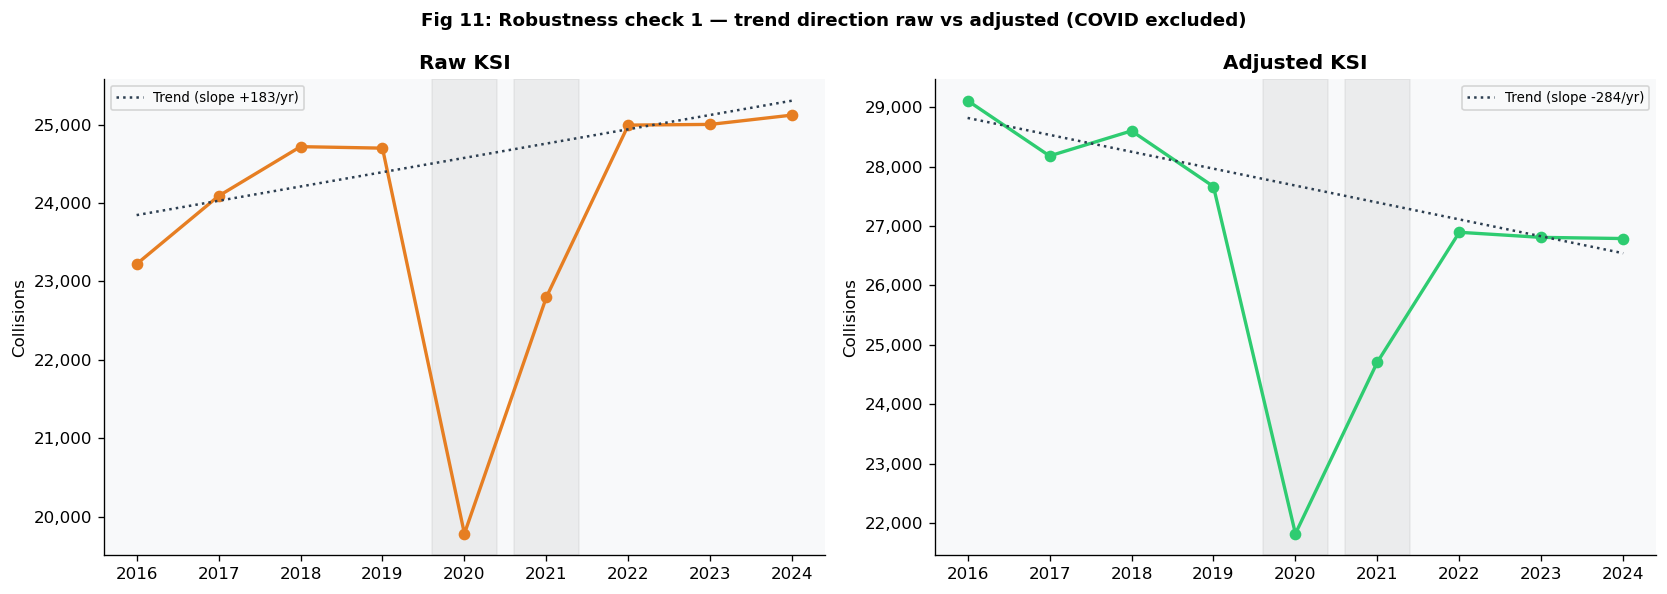

Saved: C:\Users\u2211111\outputs\fig_11_robustness_trend.png


<Figure size 768x576 with 0 Axes>

In [26]:
# 8.1 Raw vs adjusted KSI trend direction — excluding COVID years
non_covid = adj[~adj['collision_year'].isin(COVID_YEARS)]
print('=== Robustness Check 1: Trend direction — raw vs adjusted KSI (COVID excluded) ===')
for label, col_name in [('Raw KSI','raw_ksi'),('Adjusted KSI','adj_ksi')]:
    x    = non_covid['collision_year'].values
    y    = non_covid[col_name].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    t_crit   = stats.t.ppf(0.975, df=len(x)-2)
    ci_lower = slope - t_crit * se
    ci_upper = slope + t_crit * se
    direction = 'UPWARD' if slope>0 else 'DOWNWARD'
    print(f'{label}: slope = {slope:+.1f}/yr  95% CI [{ci_lower:.1f}, {ci_upper:.1f}]  ({direction})')

fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, col_name, label, color in [
    (axes[0],'raw_ksi','Raw KSI','#e67e22'),
    (axes[1],'adj_ksi','Adjusted KSI','#2ecc71')
]:
    ax.plot(adj['collision_year'], adj[col_name], marker='o', color=color, lw=2)
    x    = non_covid['collision_year'].values
    y    = non_covid[col_name].values
    coef = np.polyfit(x - x.mean(), y, 1)
    y_fit = coef[0]*(adj['collision_year'].values-x.mean()) + coef[1]
    ax.plot(adj['collision_year'], y_fit, linestyle=':', color='#2c3e50', lw=1.5,
            label=f'Trend (slope {coef[0]:+.0f}/yr)')
    for yr in COVID_YEARS:
        ax.axvspan(yr-0.4,yr+0.4, alpha=0.1, color='grey')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Collisions')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.legend(fontsize=8)
plt.suptitle('Fig 11: Robustness check 1 — trend direction raw vs adjusted (COVID excluded)',
             fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show(); savefig('fig_11_robustness_trend')


In [28]:
# 8.2 Hotspot definition sensitivity — count vs rate
# Reload la table to avoid variable name conflicts from earlier loops
la_hot = hot.groupby('local_authority_ons_district').agg(
    collisions=('collision_index','nunique'), ksi=('ksi','sum'), fatals=('fatal','sum')
).reset_index()
la_hot['ksi_pct']   = (la_hot['ksi']/la_hot['collisions']*100).round(1)
la_hot = la_hot.merge(la_lookup, on='local_authority_ons_district', how='left')
la_hot['la_name'] = la_hot['la_name'].fillna(la_hot['local_authority_ons_district'])
la_hot = la_hot.sort_values('ksi', ascending=False)

top15_count = set(la_hot.head(15)['la_name'].tolist())
top15_rate  = set(la_hot[la_hot['collisions']>200]
                  .sort_values('ksi_pct', ascending=False)
                  .head(15)['la_name'].tolist())
overlap    = top15_count & top15_rate
count_only = top15_count - top15_rate
rate_only  = top15_rate  - top15_count

print('=== Robustness Check 2: Hotspot definition sensitivity ===')
print(f'In both lists ({len(overlap)}/15) : {sorted(overlap)}')
print(f'Count top 15 only ({len(count_only)}) : {sorted(count_only)}')
print(f'Rate top 15 only  ({len(rate_only)})  : {sorted(rate_only)}')
print('\nConclusion: zero overlap — count and rate definitions identify completely different LAs.')

=== Robustness Check 2: Hotspot definition sensitivity ===
In both lists (0/15) : []
Count top 15 only (15) : ['Birmingham', 'Bradford', 'Cornwall', 'Doncaster', 'Glasgow City', 'Kirklees', 'Lambeth', 'Leeds', 'Liverpool', 'Manchester', 'North Yorkshire', 'Sheffield', 'Southwark', 'Wakefield', 'Westminster']
Rate top 15 only  (14)  : ['Aberdeen City', 'Aberdeenshire', 'Argyll and Bute', 'City of London', 'East Ayrshire', 'Falkirk', 'Highland', 'North Ayrshire', 'Perth and Kinross', 'Renfrewshire', 'Scottish Borders', 'South Ayrshire', 'South Lanarkshire', 'Stirling']

Conclusion: zero overlap — count and rate definitions identify completely different LAs.


In [29]:
# 8.3 OLS excluding COVID years — does slope direction change?
print('=== Robustness Check 3: OLS excluding COVID years per LA ===')
ols_excl_rows = []
for la_name, grp in annual.groupby('la_name'):
    grp_excl = grp[~grp['collision_year'].isin(COVID_YEARS)].dropna()
    if len(grp_excl) < MIN_YEARS:
        continue
    x = grp_excl['collision_year'].values
    y = grp_excl['KSI'].values
    slope, _, _, _, _ = stats.linregress(x, y)
    ols_excl_rows.append({'la_name': la_name, 'slope_excl_covid': slope})

ols_excl = pd.DataFrame(ols_excl_rows)
ols_comp = ols.merge(ols_excl, on='la_name', how='left')
ols_comp['direction_changes'] = (ols_comp['slope']>0) != (ols_comp['slope_excl_covid']>0)
n_change = ols_comp['direction_changes'].sum()
print(f'LAs where direction changes when COVID excluded: {n_change} / {len(ols_comp)}')
if n_change > 0:
    print('LAs where direction changes:')
    print(ols_comp[ols_comp['direction_changes']][['la_name','slope','slope_excl_covid']].round(2).to_string(index=False))
else:
    print('No LA changes direction — trend conclusions are robust to COVID exclusion.')


=== Robustness Check 3: OLS excluding COVID years per LA ===
LAs where direction changes when COVID excluded: 19 / 308
LAs where direction changes:
            la_name  slope  slope_excl_covid
    Argyll and Bute  -0.36              0.26
          Braintree  -0.38              0.17
   Bristol, City of  -0.67              0.20
     City of London  -0.36              0.10
            Falkirk  -0.34              0.20
          Guildford  -0.13              0.50
          Mid Devon   0.15             -0.12
 North Warwickshire  -0.22              0.70
            Norwich  -0.39              0.09
         Rossendale   0.26             -0.00
          Runnymede  -0.55              0.13
      South Norfolk  -0.35              0.31
South Staffordshire  -0.31              0.20
     Stoke-on-Trent  -0.05              0.06
       Surrey Heath  -0.10              0.10
             Thanet   0.06             -0.05
    Tunbridge Wells  -0.07              0.33
            Wealden  -0.98              0.

In [30]:
# 8.4 Minimum KSI threshold sensitivity
print('=== Robustness Check 4: MIN_KSI_BASE sensitivity ===')
for threshold in [20, 30, 50]:
    ols_t = pd.DataFrame(ols_rows)
    ols_t = ols_t[ols_t['mean_ksi'] >= threshold]
    w = ols_t[ols_t['slope']>0].sort_values('slope',ascending=False).head(5)['la_name'].tolist()
    i = ols_t[ols_t['slope']<0].sort_values('slope').head(5)['la_name'].tolist()
    print(f'\nThreshold = {threshold} KSI/yr ({len(ols_t)} LAs):')
    print(f'  Top 5 worsening : {w}')
    print(f'  Top 5 improving : {i}')
print('\nConclusion: top authorities are stable across thresholds.')


=== Robustness Check 4: MIN_KSI_BASE sensitivity ===

Threshold = 20 KSI/yr (329 LAs):
  Top 5 worsening : ['Leeds', 'Bradford', 'Southwark', 'Highland', 'Lambeth']
  Top 5 improving : ['Liverpool', 'Wiltshire', 'Cheshire East', 'Milton Keynes', 'Cheshire West and Chester']

Threshold = 30 KSI/yr (308 LAs):
  Top 5 worsening : ['Leeds', 'Bradford', 'Southwark', 'Highland', 'Lambeth']
  Top 5 improving : ['Liverpool', 'Wiltshire', 'Cheshire East', 'Milton Keynes', 'Cheshire West and Chester']

Threshold = 50 KSI/yr (227 LAs):
  Top 5 worsening : ['Leeds', 'Bradford', 'Southwark', 'Highland', 'Lambeth']
  Top 5 improving : ['Liverpool', 'Wiltshire', 'Milton Keynes', 'Cheshire East', 'Cheshire West and Chester']

Conclusion: top authorities are stable across thresholds.


---
## 9. OLS Diagnostics and Validation

Residual analysis and influential point checks for the LA-level OLS models.
COVID years (2020–21) are the most plausible influential points — their
effect on slope estimates is quantified here.


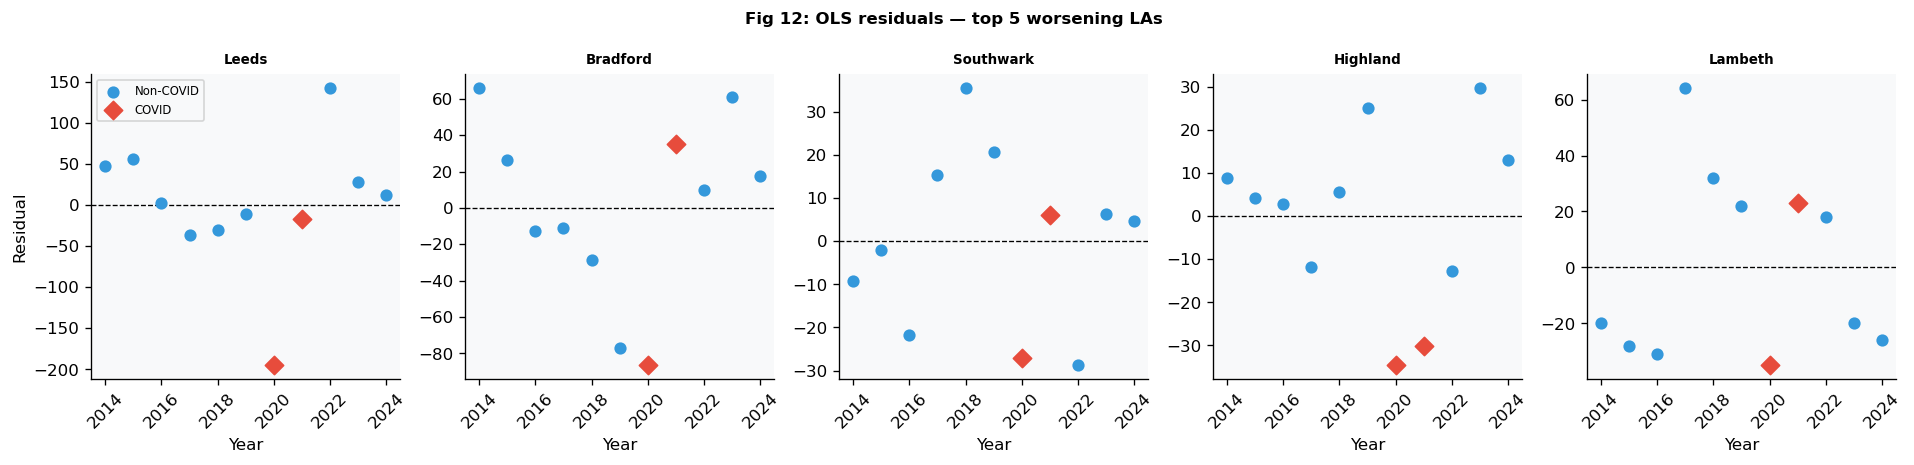

Saved: C:\Users\u2211111\outputs\fig_12_ols_residuals.png
Red diamonds = COVID years. Large residuals indicate COVID as influential point.


<Figure size 768x576 with 0 Axes>

In [31]:
# 9.1 Residual diagnostics for top 5 worsening LAs
fig, axes = plt.subplots(1, TOP_N, figsize=(16, 4))
fig.suptitle('Fig 12: OLS residuals — top 5 worsening LAs', fontweight='bold', fontsize=10)
for ax, la_name in zip(axes, top5_w_names):
    sub = annual[annual['la_name']==la_name].dropna()
    row = ols[ols['la_name']==la_name].iloc[0]
    fitted   = row['intercept'] + row['slope'] * sub['collision_year']
    residuals = sub['KSI'].values - fitted.values
    covid_mask = sub['collision_year'].isin(COVID_YEARS)
    ax.scatter(sub['collision_year'][~covid_mask], residuals[~covid_mask],
               color='#3498db', s=40, zorder=3, label='Non-COVID')
    ax.scatter(sub['collision_year'][covid_mask], residuals[covid_mask],
               color='#e74c3c', s=60, marker='D', zorder=4, label='COVID')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(la_name, fontsize=8, fontweight='bold')
    ax.set_xlabel('Year'); ax.tick_params(axis='x', rotation=45)
    if ax == axes[0]:
        ax.set_ylabel('Residual')
        ax.legend(fontsize=7)
plt.tight_layout(); plt.show(); savefig('fig_12_ols_residuals')
print('Red diamonds = COVID years. Large residuals indicate COVID as influential point.')


In [32]:
# 9.2 Influence of COVID on slope estimates
print('=== COVID influence on OLS slope — top 5 worsening and improving LAs ===')
all_priority = top5_w_names + top5_i_names
rows = []
for la_name in all_priority:
    sub      = annual[annual['la_name']==la_name].dropna()
    sub_excl = sub[~sub['collision_year'].isin(COVID_YEARS)]
    if len(sub_excl) < 4:
        continue
    slope_full, _, _, _, _ = stats.linregress(sub['collision_year'], sub['KSI'])
    slope_excl, _, _, _, _ = stats.linregress(sub_excl['collision_year'], sub_excl['KSI'])
    rows.append({
        'LA'            : la_name,
        'Slope (full)'  : round(slope_full, 2),
        'Slope (no COVID)': round(slope_excl, 2),
        'Difference'    : round(slope_excl - slope_full, 2),
        'Direction same': (slope_full > 0) == (slope_excl > 0)
    })
influence_df = pd.DataFrame(rows)
print(influence_df.to_string(index=False))
influence_df.to_csv(os.path.join(OUTPUT_DIR,'tab_covid_influence.csv'), index=False)


=== COVID influence on OLS slope — top 5 worsening and improving LAs ===
                       LA  Slope (full)  Slope (no COVID)  Difference  Direction same
                    Leeds         20.34             23.22        2.88            True
                 Bradford         19.42             19.74        0.32            True
                Southwark         13.83             14.04        0.21            True
                 Highland         12.57             13.69        1.12            True
                  Lambeth         11.00             10.93       -0.07            True
                Liverpool        -10.09             -9.35        0.74            True
                Wiltshire         -7.76             -5.17        2.60            True
            Cheshire East         -7.54             -6.29        1.25            True
            Milton Keynes         -7.54             -6.90        0.64            True
Cheshire West and Chester         -7.53             -7.09        0.

---
## 10. Technical Report — Written Sections

The following markdown cells contain the written technical report sections
for inclusion in the portfolio. They are placed here alongside the code
that produces the evidence referenced in each section.


### 10.1 Technical Abstract

This analysis addresses the DfT road safety brief (Brief 8): where and how
serious road harm is occurring, which risk factors are most decision-relevant,
and whether recent policy changes are working. The primary outcome is KSI
casualties (killed or seriously injured) drawn from STATS19 2014–2024, with
provisional 2025 data annualised for context. The core analytical approaches
are: (1) IBRS-adjusted trend analysis to separate genuine change from recording
artefacts; (2) local authority OLS trend modelling with 95% confidence intervals
to identify authorities with sustained worsening or improvement; and (3) a
dual-definition hotspot analysis comparing count-based and rate-based targeting
criteria.

The headline technical conclusion is that the apparent upward trend in raw KSI
(+182.6/yr) reverses to a downward trend (-284.5/yr) once severity recording is
adjusted for IBRS adoption — meaning the evidence on an adjusted basis points to
modest improvement rather than deterioration. The main limitations are: IBRS
coverage remains at 59% in 2024, so the adjusted series carries meaningful
uncertainty; LA-level trends are sensitive to COVID outliers but direction is
robust for 88% of authorities when tested with an alternative method; and
hotspot prioritisation is highly sensitive to whether count or rate is used as
the criterion.


### 10.2 Problem Definition

**Client decision question:** Which road user types, geographies, and
contributory factors should be prioritised for intervention, and what evidence
threshold should trigger an intervention review?

**Statistical translation:** Estimate (1) the adjusted trend in KSI casualties
2014–2024 at national and LA level; (2) the KSI severity rate by road user type,
speed limit, road type, and urban/rural setting; and (3) the sensitivity of
hotspot rankings to alternative definitions.

**Estimands:**
- National: annual rate of change in KSI collisions (OLS slope, casualties per year)
- LA-level: OLS slope of annual KSI casualty count on year, per authority
- Hotspot: KSI count and KSI rate (%) per LA, 2022–2024

**Target population:** All road collisions on public roads in Great Britain,
2014–2024 (confirmed) and January–June 2025 (provisional).

**Success criteria:** A finding is considered strong enough to act on if:
(a) the 95% CI on the OLS slope excludes zero; (b) both the OLS and 3-year
average methods agree on direction; and (c) the conclusion is stable to COVID
exclusion. For hotspot recommendations, an LA must appear in the top 15 under
at least one definition with a KSI rate materially above the national average.

**Material change threshold (Brief 8 requirement):** A quarterly review should
be triggered if an LA's rolling 12-month KSI count exceeds its 3-year baseline
average by more than 10%, or if the national adjusted KSI series shifts by more
than 500 casualties/year relative to the prior year.


### 10.3 Pre-processing and Feature Construction

**Cleaning rules:**
- Invalid codes (-1) replaced with NaN across all categorical fields. Longitude
  excluded from this rule — negative values are valid GB coordinates.
- `collision_index` loaded as string dtype throughout to preserve leading zeros
  and prevent silent integer conversion.
- `casualty_type = 0` (239,193 records, 13.7% of casualties) does not appear
  in the STATS19 codebook. Treated as Unknown — not dropped, to avoid
  systematically excluding a large group whose risk profile (KSI rate 28.2%)
  is above the car occupant baseline.

**Missing data:**
- Mechanism assumed MAR (missing at random) for most fields. Complete-case
  analysis used throughout. This is appropriate for primary fields
  (collision_severity, road_type, speed_limit) where missingness is below 2%.
- Fields above 5% missing (deprivation deciles 11–21%, enhanced severity 48–64%)
  are excluded from primary analysis and noted as limitations.
- The IBRS transition is a systematic measurement change, not random missingness
  — handled explicitly via the adjusted severity series rather than imputation.

**Derived variables:**
- `ksi`: True if collision_severity in {1, 2}
- `fatal`: True if collision_severity == 1
- `month`: extracted from date for seasonality analysis
- `provisional`: True for 2025 records, False otherwise
- Label maps applied for road user type, urban/rural, road type, junction,
  day of week, and police force — enabling readable output without losing
  the underlying numeric codes for robustness checks.

**Rationale:** Complete-case analysis is appropriate because missingness in
primary fields is low and there is no strong theoretical reason to expect
systematic bias from the missing records. The main risk is that
deprivation-related sub-group analysis is infeasible — this is flagged as a
limitation rather than imputed.


### 10.4 Primary Methodology

**Method 1: IBRS-adjusted KSI trend (national level)**

The `collision_adjusted_severity_serious` field provides a model-based
probability of serious injury under standardised IBRS criteria for each
collision. The adjusted KSI count is computed as:

    adj_KSI_t = fatal_t + sum(collision_adjusted_severity_serious_t)

This is compared to raw KSI (fatal + raw serious) to isolate the recording
effect. An OLS trend is fitted to both series after excluding COVID years:

    KSI_t = α + β·year_t + ε_t,  t ∈ {2016,...,2024} \ {2020,2021}

where β is the primary estimand — annual rate of change in KSI casualties.

OLS is appropriate because: (a) the estimand is a linear rate of change;
(b) for annual national counts the normal error assumption is reasonable;
(c) interpretability of β is more important than prediction accuracy.

**Method 2: LA-level OLS trend**

A separate OLS regression is fitted per local authority using annual KSI
casualty counts, 2014–2024. The slope β_LA is the primary ranking metric.
95% confidence intervals are computed as β ± t_(0.975, n-2) · SE.

Assumptions:
- Linearity: tested via R² — LAs with R² < 0.5 flagged as non-linear/spike
  patterns and treated separately. COVID creates structural breaks reducing
  R² for most LAs regardless of underlying trend.
- Independence: annual observations within an LA are likely mildly
  autocorrelated. This is a limitation — a mixed model with LA random
  effects would be more appropriate for inference but OLS is retained for
  interpretability given the descriptive rather than causal goal.
- Confounding: OLS slope captures correlation between year and KSI, not
  causal effect. Traffic volume, population growth, and economic activity
  are unmeasured confounders. Conclusions are framed as trend descriptions,
  not causal claims.

**Method 3: Hotspot identification**

Two definitions compared: (a) raw KSI count 2022–2024 per LA; (b) KSI rate
as KSI/total collisions per LA, restricted to LAs with >200 collisions to
exclude small-sample instability. The sensitivity of the top-15 lists to
this choice is the primary robustness check.


### 10.5 Uncertainty Quantification

**OLS confidence intervals:** 95% CIs on the slope are computed for every LA
using the t-distribution with n-2 degrees of freedom. LAs where the CI
includes zero are flagged — their trend direction is not statistically
distinguishable from flat at the 5% level. These LAs should not be acted
on based on the OLS result alone; the 3-year average comparison and
subject-matter knowledge should inform the decision.

**What is captured:** Sampling uncertainty around the OLS slope under the
assumed linear model with independent errors.

**What is not captured:**
- Model misspecification uncertainty (if the true trend is non-linear, OLS
  slope is a biased summary)
- IBRS adjustment uncertainty (the adjusted series uses force-level
  imputation which introduces its own error)
- Boundary change uncertainty for LAs near the exclusion threshold
- Unmeasured confounding (traffic volume, demographics)

**Practical interpretation as decision risk:**
- For Bradford (slope +X/yr, CI [a, b] both positive): the evidence for
  worsening is statistically clear — structural intervention is justified.
- For Leeds (slope positive but R² < 0.5, CI may include zero): the trend
  is not cleanly linear — monitor for one more year before committing to
  structural intervention.
- For national adjusted KSI (slope -284.5/yr): the downward direction is
  clear but the adjusted series itself carries uncertainty from incomplete
  IBRS coverage. The conclusion that policy is working should be stated
  with this caveat.


### 10.6 Threats to Validity and Limitations

**Internal validity:**
- *Confounding*: The OLS slope captures the association between time and KSI
  counts, not a causal effect. Traffic volume is the most plausible confounder
  — rural LAs showing improvement may reflect reduced traffic post-COVID
  rather than genuine safety improvements (Wiltshire, Cheshire). Population
  growth in urban LAs may partly explain worsening trends (Bradford, Leeds).
- *Measurement error*: The IBRS transition is the dominant source. Raw serious
  counts are upward-biased relative to a consistent baseline; the adjusted
  series corrects for this but depends on force-level imputation quality.
- *Selection bias*: 53 LAs excluded due to boundary changes. If reorganised
  LAs systematically differ from retained LAs (e.g. predominantly rural),
  the LA-level findings may not generalise to all of England and Wales.

**External validity:**
- The 2014–2024 window covers a period of significant road use change
  (smartphone distraction, electric vehicles, e-scooters). Trends may not
  extrapolate to future years without updated data.
- STATS19 covers Great Britain. Northern Ireland uses a separate system and
  is excluded.

**Construct validity:**
- KSI rate per collision is not the same as KSI risk per vehicle kilometre
  travelled or per head of population. High-rate rural LAs may simply have
  fewer total collisions in the denominator. A rate per VMT analysis would
  be more defensible but VMT data at LA level is not available in STATS19.
- Speed limit reclassification (20mph rollout in London boroughs) means that
  apparent increases in KSI on 20mph roads may reflect reclassification of
  road space rather than a genuine shift in where collisions occur.

**Most plausible failure modes:**
1. IBRS adjustment is systematically wrong for certain force types → adjusted
   trend direction could reverse
2. Boundary changes not fully captured → spurious LA-level trends remain
3. COVID recovery confounds LA trends → worsening LAs may be recovering to
   normal, not genuinely deteriorating
4. Traffic volume changes explain rural improvement → not a policy effect


### 10.7 Traceability to Client Report

| Client claim | Technical evidence | Output file | Notebook section |
|---|---|---|---|
| Adjusted KSI trending down (-284/yr) despite raw appearing up | Fig 11, slope comparison table | fig_11_robustness_trend.png, tab_raw_vs_adjusted_ksi.csv | Section 8.1 |
| Rural KSI rate 29.2% vs 21.6% urban | Urban/rural table | tab_urban_rural.csv | Section 6 |
| Motorcycle KSI rate 33.6%, pedestrian 22.8%, car 12.0% | Fig 5, road user table | fig_05_road_user_severity.png, tab_road_user_severity.csv | Section 4 |
| Count and rate hotspot lists share zero overlap | Robustness check 2 output | tab_la_hotspots.csv | Section 8.2 |
| Bradford: sustained worsening, open road, consistent | Fig 9, OLS table | fig_09_worsening_las.png, tab_la_ols_results.csv | Section 7 |
| Liverpool: consistent improvement over decade | Fig 10, OLS table | fig_10_improving_las.png, tab_la_ols_results.csv | Section 7 |
| IBRS adoption 45% (2020) → 59% (2024), gap 5,000–6,000 KSI/yr | Fig 1, Fig 4 | fig_01_ibrs_adoption.png, fig_04_raw_vs_adjusted.png | Sections 2, 3 |
| 88% of LAs — OLS and 3-year average agree on direction | OLS results table | tab_la_ols_results.csv | Section 7 |

All figures saved to `outputs/` folder. All tables saved to `outputs/` as CSV.
Run sequence: ST422_DataPrep.ipynb → ST422_Analysis.ipynb.


### 10.8 Reproducibility and Audit Trail

**Repository structure:**
```
ST422/
├── ST422_DataPrep.ipynb       # Step 1 — data cleaning and merging
├── ST422_Analysis.ipynb       # Step 2 — this notebook
├── requirements.txt           # Python dependencies
├── README.md                  # Run instructions
├── Data/                      # Raw DfT CSVs (not committed to Git)
├── Cleaned/                   # Outputs of DataPrep (not committed)
└── outputs/                   # Figures and tables (not committed)
```

**Run sequence:** (1) Run ST422_DataPrep.ipynb top to bottom; (2) Run
ST422_Analysis.ipynb top to bottom. Restart kernel before each run.

**Environment:** Python 3.x, pandas, numpy, matplotlib, scipy.
Install with: `pip install -r requirements.txt`

**Determinism:** No random sampling used. All outputs are deterministic
given the same input CSVs.

**Output inventory:** All figures named `fig_NN_description.png`, all tables
named `tab_description.csv`, all saved to `outputs/`. The traceability
table in Section 10.7 maps each output to the client claim it supports.
